# EDA for Mexico's official air emissions inventory 

In [94]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns 

## 1. Cleaning the Dataframe 

In [95]:
url = 'https://raw.githubusercontent.com/AndrsGzRo/mexico-emissions-eda-ml/refs/heads/main/data-2025-11-19.csv'
df_raw = pd.read_csv(url)
#First 5 rows
df_raw.head()

,Entidad_federativa,Municipio,Tipo_de_Fuente,SO_2,CO,NOx,COV,PM_010,PM_2_5,NH_3,Entidad
0,Aguascalientes,Aguascalientes,Fuentes fijas,546.316,94.308,209.404,2219.396,246.873,182.143,2.929,Aguascalientes
1,Aguascalientes,Aguascalientes,Fuentes de área,15.877,2396.298,333.306,12438.827,1567.037,483.104,13661.221,Aguascalientes
2,Aguascalientes,Aguascalientes,Fuentes móviles carreteros,308.001,48527.124,10486.580,5148.961,721.389,659.929,83.887,Aguascalientes
3,Aguascalientes,Aguascalientes,Fuentes móviles que no circulan por carretera,36.981,548.796,1042.305,96.899,66.318,63.940,0.226,Aguascalientes
4,Aguascalientes,Aguascalientes,Fuentes naturales,NaN,NaN,440.268,1663.833,NaN,NaN,NaN,Aguascalientes


### 1.1 General information

In [96]:
def info_df(df):
    print('---------General information of the  Dataframe---------')
    print(df.info())
    print('---------Dataframe stats---------')
    print(df.describe())
    print('---------Null Values---------')
    print(df.isnull().sum().sort_values(ascending=False))
    print('---------Unique Values---------')
    print(df.nunique())

info_df(df_raw)
     

---------General information of the  Dataframe---------
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10521 entries, 0 to 10520
Data columns (total 11 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Entidad_federativa  10521 non-null  object 
 1   Municipio           10521 non-null  object 
 2   Tipo_de_Fuente      10521 non-null  object 
 3   SO_2                8068 non-null   float64
 4   CO                  8068 non-null   float64
 5   NOx                 10521 non-null  float64
 6   COV                 10521 non-null  float64
 7   PM_010              8068 non-null   float64
 8   PM_2_5              8068 non-null   float64
 9   NH_3                8068 non-null   float64
 10  Entidad             10521 non-null  object 
dtypes: float64(7), object(4)
memory usage: 904.3+ KB
None
---------Dataframe stats---------
                SO_2            CO           NOx            COV        PM_010  \
count    8068.000000   8

### 1.2 Dropping Columns

In [97]:
df = df_raw.copy()
df = df.drop(columns=['Entidad'],axis=1)
df.head()

,Entidad_federativa,Municipio,Tipo_de_Fuente,SO_2,CO,NOx,COV,PM_010,PM_2_5,NH_3
0,Aguascalientes,Aguascalientes,Fuentes fijas,546.316,94.308,209.404,2219.396,246.873,182.143,2.929
1,Aguascalientes,Aguascalientes,Fuentes de área,15.877,2396.298,333.306,12438.827,1567.037,483.104,13661.221
2,Aguascalientes,Aguascalientes,Fuentes móviles carreteros,308.001,48527.124,10486.580,5148.961,721.389,659.929,83.887
3,Aguascalientes,Aguascalientes,Fuentes móviles que no circulan por carretera,36.981,548.796,1042.305,96.899,66.318,63.940,0.226
4,Aguascalientes,Aguascalientes,Fuentes naturales,NaN,NaN,440.268,1663.833,NaN,NaN,NaN


### 1.3 Correction of Mexican States

In [98]:
df = df.replace({
    'México':'Estado de México'
})
df['Entidad_federativa'].unique()

array(['Aguascalientes', 'Baja California', 'Baja California Sur',
       'Campeche', 'Coahuila', 'Colima', 'Chiapas', 'Chihuahua',
       'Ciudad de México', 'Durango', 'Guanajuato', 'Guerrero', 'Hidalgo',
       'Jalisco', 'Estado de México', 'Michoacán', 'Morelos', 'Nayarit',
       'Nuevo León', 'Oaxaca', 'Puebla', 'Querétaro', 'Quintana Roo',
       'San Luis Potosí', 'Sinaloa', 'Sonora', 'Tabasco', 'Tamaulipas',
       'Tlaxcala', 'Veracruz', 'Yucatán', 'Zacatecas'], dtype=object)

### 1.4 Homogenizing Names

In [99]:
df['Entidad_federativa'] = df['Entidad_federativa'].str.title().str.strip()
df['Municipio'] = df['Municipio'].str.title().str.strip()
df['Tipo_de_Fuente'] = df['Tipo_de_Fuente'].str.title().str.strip()


### 1.5 Null values
We will drop ```NaN``` values

In [100]:
df_clean = df.dropna()
# Information for the clean dataframe
info_df(df_clean)

---------General information of the  Dataframe---------
<class 'pandas.core.frame.DataFrame'>
Index: 8068 entries, 0 to 10519
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Entidad_federativa  8068 non-null   object 
 1   Municipio           8068 non-null   object 
 2   Tipo_de_Fuente      8068 non-null   object 
 3   SO_2                8068 non-null   float64
 4   CO                  8068 non-null   float64
 5   NOx                 8068 non-null   float64
 6   COV                 8068 non-null   float64
 7   PM_010              8068 non-null   float64
 8   PM_2_5              8068 non-null   float64
 9   NH_3                8068 non-null   float64
dtypes: float64(7), object(3)
memory usage: 693.3+ KB
None
---------Dataframe stats---------
                SO_2            CO           NOx           COV        PM_010  \
count    8068.000000   8068.000000   8068.000000   8068.000000   8068.000000   


### 1.6 Municipio (Estado)

In [101]:
abrev_estados = {
    "Aguascalientes": "AGS", "Baja California": "BC", "Baja California Sur": "BCS",
    "Campeche": "CAM", "Coahuila": "COAH", "Colima": "COL", "Chiapas": "CHIS",
    "Chihuahua": "CHIH", "Ciudad de México": "CDMX", "Durango": "DGO",
    "Guanajuato": "GTO", "Guerrero": "GRO", "Hidalgo": "HGO", "Jalisco": "JAL",
    "México": "MEX", "Michoacán": "MICH", "Morelos": "MOR", "Nayarit": "NAY",
    "Nuevo León": "NL", "Oaxaca": "OAX", "Puebla": "PUE", "Querétaro": "QRO",
    "Quintana Roo": "QROO", "San Luis Potosí": "SLP", "Sinaloa": "SIN",
    "Sonora": "SON", "Tabasco": "TAB", "Tamaulipas": "TAM", "Tlaxcala": "TLAX",
    "Veracruz": "VER", "Yucatán": "YUC", "Zacatecas": "ZAC"
}
df_clean['Abrev'] = df_clean['Entidad_federativa'].map(abrev_estados)
df_clean['Municipio_Estado'] = df_clean['Municipio'] + ' (' + df_clean['Abrev']+')'

C:\Users\Andre\AppData\Local\Temp\ipykernel_22188\3114866673.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_clean['Abrev'] = df_clean['Entidad_federativa'].map(abrev_estados)
C:\Users\Andre\AppData\Local\Temp\ipykernel_22188\3114866673.py:13: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_clean['Municipio_Estado'] = df_clean['Municipio'] + ' (' + df_clean['Abrev']+')'


In [102]:
renombrar = {
    "Fuentes Móviles Carreteros": "Móviles Carretera",
    "Fuentes Móviles Que No Circulan Por Carretera": "Móviles No Carretera",
    "Fuentes Fijas": "Fijas",
    "Fuentes De Área": "Área"
}
df_clean['Tipo_de_Fuente']  = df_clean['Tipo_de_Fuente'].replace(renombrar)


C:\Users\Andre\AppData\Local\Temp\ipykernel_22188\1403568631.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_clean['Tipo_de_Fuente']  = df_clean['Tipo_de_Fuente'].replace(renombrar)


## 2. EDA 

In [103]:

sns.set_theme(style='darkgrid')

### 2.1 Sources

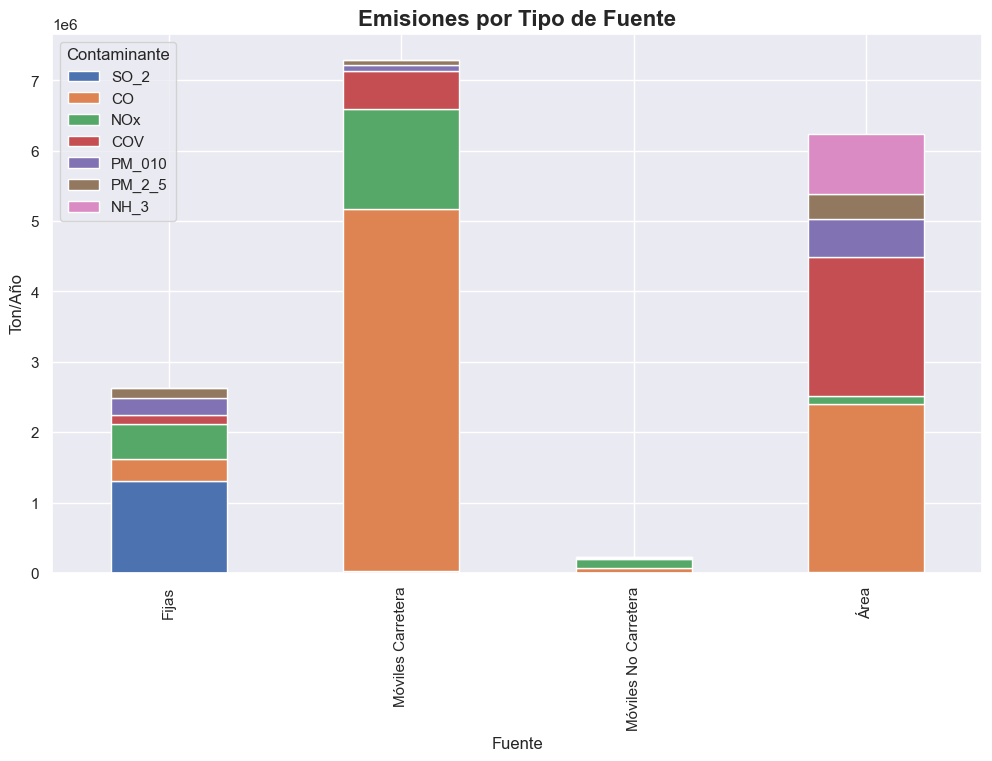

In [104]:
df_sources = (
    df_clean.groupby('Tipo_de_Fuente')[['SO_2','CO','NOx','COV','PM_010','PM_2_5','NH_3']].sum()
)
df_sources.plot(kind='bar',stacked=True,figsize=(12,7))
plt.ylabel('Ton/Año')
plt.xlabel('Fuente')
plt.title('Emisiones por Tipo de Fuente',fontsize=16,fontweight='bold')
plt.legend(title='Contaminante')
plt.show()

### 2.2 Top 10 Estados más contaminantes

In [105]:
contaminantes = ['SO_2','CO','NOx','COV','PM_010','PM_2_5','NH_3']
df_estados = (
    df_clean.groupby('Entidad_federativa')[contaminantes].sum()
)
df_estados['Total_Emissions'] = df_estados.sum(axis=1)

top10_estados= df_estados.sort_values('Total_Emissions',ascending=False).head(10).reset_index()
top10_estados['Total_Emissions_mill'] = top10_estados['Total_Emissions']/1e6
top10_estados

,Entidad_federativa,SO_2,CO,NOx,COV,PM_010,PM_2_5,NH_3,Total_Emissions,Total_Emissions_mill
0,Estado De México,2360.316,661877.254,156741.394,289898.726,32554.221,23754.217,46868.176,1214054.304,1.214054
1,Veracruz,115991.744,464826.694,130213.593,170148.672,82461.191,58055.509,74240.942,1095938.345,1.095938
2,Jalisco,14595.495,526650.643,108097.199,198160.359,62033.682,40990.440,95491.484,1046019.302,1.046019
3,Chihuahua,17952.086,517438.072,91503.420,101408.282,44607.330,30134.224,26442.255,829485.669,0.829486
4,Michoacán,14328.650,506962.053,90012.537,108693.635,36143.447,25380.911,24750.109,806271.342,0.806271
5,Guanajuato,17898.861,125731.867,308103.854,167829.518,30578.866,17908.985,34559.227,702611.178,0.702611
6,Hidalgo,203049.777,266693.827,63808.655,71159.272,47264.841,26315.235,24042.578,702334.185,0.702334
7,Guerrero,80461.701,384308.692,50372.042,90739.055,29227.164,24019.597,22572.550,681700.801,0.681701
8,Coahuila,212121.972,205627.866,110596.740,63685.082,36394.790,24610.467,15996.950,669033.867,0.669034
9,Puebla,8396.729,331021.554,71539.773,123151.728,32006.684,24350.858,55471.150,645938.476,0.645938


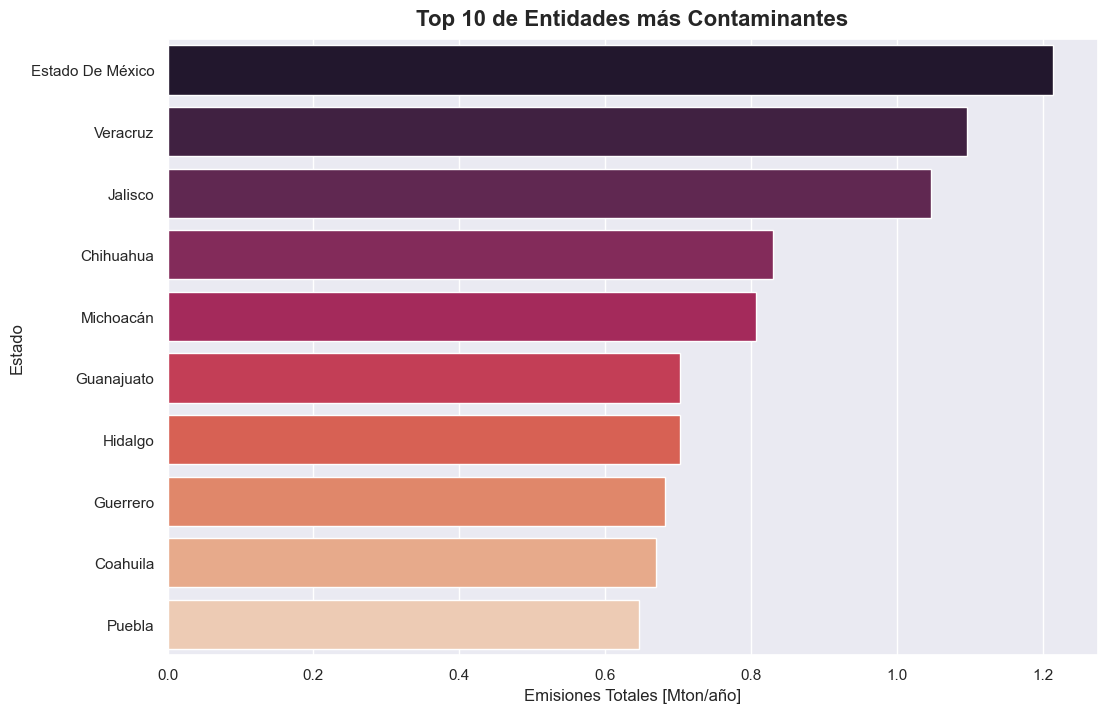

In [106]:
plt.figure(figsize=(12,8))
sns.barplot(
    data=top10_estados,
    x='Total_Emissions_mill',
    y='Entidad_federativa',
    palette='rocket',
    hue='Entidad_federativa'
)
plt.xlabel('Emisiones Totales [Mton/año]')
plt.ylabel('Estado')
plt.title('Top 10 de Entidades más Contaminantes',fontsize=16,fontweight='bold',pad=10)
plt.show()

### 2.3 Top 10 Estados que menos Contaminan

In [107]:
df_estados_m = (
    df_clean.groupby('Entidad_federativa')[contaminantes].sum()
)
df_estados_m['Total_Emissions'] = df_estados.sum(axis=1)

top10_estados_m= df_estados_m.sort_values('Total_Emissions',ascending=True).head(10).reset_index()
top10_estados_m

,Entidad_federativa,SO_2,CO,NOx,COV,PM_010,PM_2_5,NH_3,Total_Emissions
0,Tlaxcala,792.110,80600.089,19271.953,25900.711,5412.352,3501.449,6077.553,283112.434
1,Aguascalientes,3806.754,72606.138,18792.754,27723.238,5730.027,3040.429,46759.670,356918.020
2,Zacatecas,805.134,96871.966,24988.157,26563.910,15458.672,7231.974,14415.775,372671.176
3,Colima,47257.913,73587.788,23063.637,17345.366,13511.010,9927.084,4525.115,378435.826
4,Nayarit,943.741,128225.882,17179.966,26485.617,11501.947,8880.888,9420.913,405277.908
5,Baja California Sur,38207.063,94713.069,52091.173,18182.481,7731.074,2890.774,2016.594,431664.456
6,Morelos,1010.471,141628.124,28566.360,40497.537,10446.257,7795.702,9949.280,479787.462
7,Querétaro,4136.565,108435.719,39768.580,53496.703,10237.540,7084.704,42239.419,530798.460
8,Quintana Roo,1517.384,165959.528,30415.359,38004.443,18338.979,9315.505,4544.311,536191.018
9,Durango,23211.240,141985.288,36314.893,34914.837,17521.338,12155.211,43711.154,619627.922


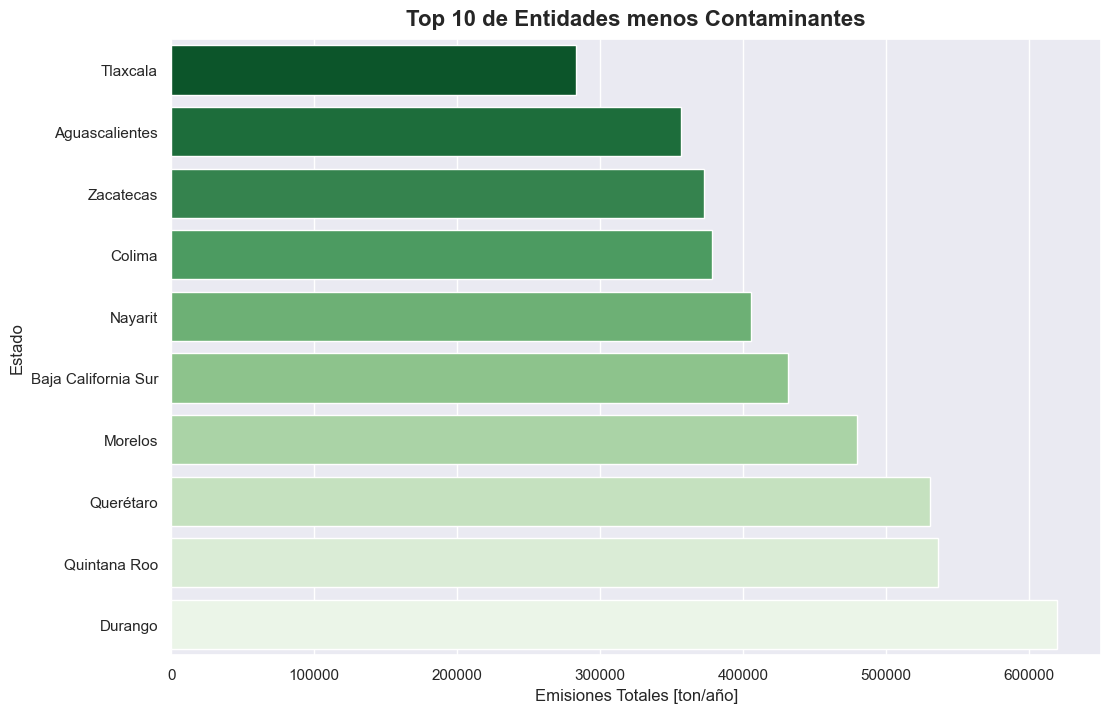

In [108]:
plt.figure(figsize=(12,8))
sns.barplot(
    data=top10_estados_m,
    x='Total_Emissions',
    y='Entidad_federativa',
    palette='Greens_r',
    hue='Entidad_federativa'
)
plt.xlabel('Emisiones Totales [ton/año]')
plt.ylabel('Estado')
plt.title('Top 10 de Entidades menos Contaminantes',fontsize=16,fontweight='bold',pad=10)
plt.show()

### 2.4 Top 10 Municipios más Contaminantes

In [109]:
df_mun = (
    df_clean.groupby('Municipio_Estado')[contaminantes].sum()
)
df_mun['Total_emisiones'] = df_mun.sum(axis=1)
top10_mun = df_mun.sort_values('Total_emisiones',ascending=False).head(10).reset_index()
top10_mun

,Municipio_Estado,SO_2,CO,NOx,COV,PM_010,PM_2_5,NH_3,Total_emisiones
0,Nava (COAH),202394.661,5087.044,41962.470,654.300,8782.945,5557.958,89.000,264528.378
1,Juárez (CHIH),499.770,101710.181,32206.449,32293.898,2723.511,2424.192,1723.699,173581.700
2,Tula De Allende (HGO),114143.674,20070.221,16718.514,2578.989,7302.418,4813.649,667.339,166294.804
3,Campeche (CAM),105380.750,33441.040,10188.799,7368.817,3040.271,2284.896,2799.865,164504.438
4,Chihuahua (CHIH),3429.706,99364.377,26884.356,23572.840,3824.409,3121.968,1460.649,161658.305
5,Guadalajara (JAL),592.068,87601.908,22284.619,42885.360,1612.289,837.255,218.842,156032.341
6,Tijuana (BC),979.422,81243.427,22142.232,39585.844,2572.760,1989.604,2060.092,150573.381
7,Puebla (PUE),1074.918,87886.295,20705.691,30022.042,2063.528,1799.812,1904.764,145457.050
8,Morelia (MICH),908.458,100744.944,18332.566,19342.860,1918.517,1534.709,2415.818,145197.872
9,Reynosa (TAM),32608.122,60972.831,23190.039,17888.798,3608.059,2372.114,1603.406,142243.369


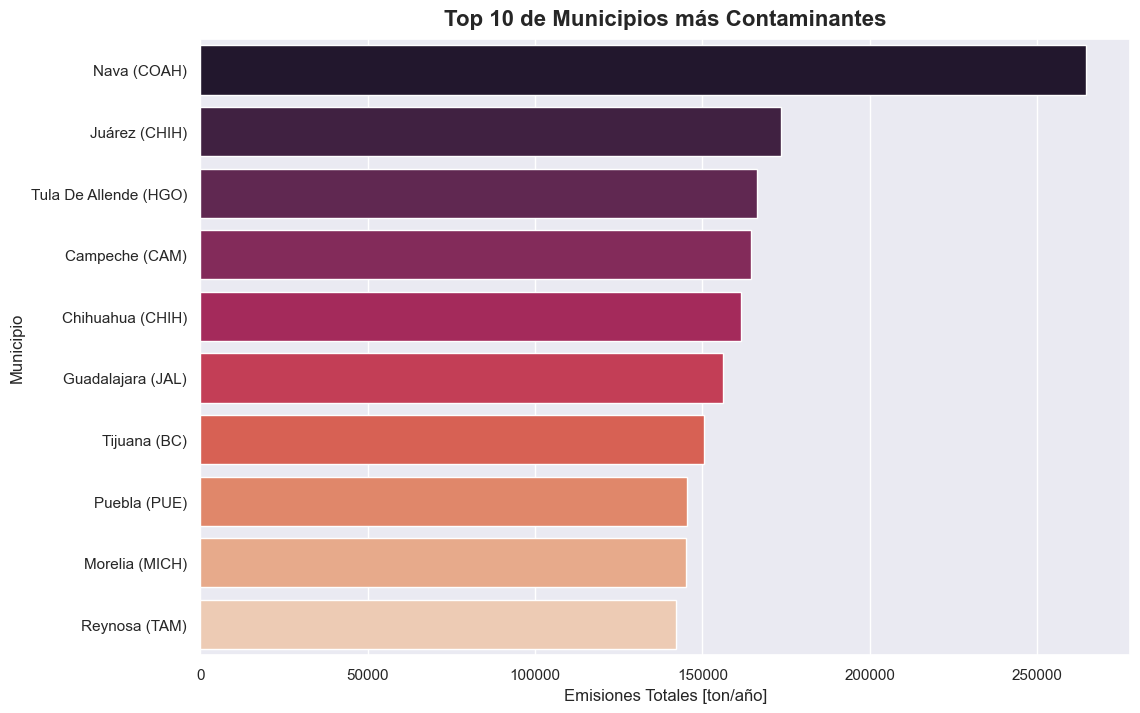

In [110]:
plt.figure(figsize=(12,8))
sns.barplot(
    data=top10_mun,
    x='Total_emisiones',
    y='Municipio_Estado',
    palette='rocket',
    hue='Municipio_Estado'
)
plt.xlabel('Emisiones Totales [ton/año]')
plt.ylabel('Municipio')
plt.title('Top 10 de Municipios más Contaminantes',fontsize=16,fontweight='bold',pad=10)
plt.show()

### 2.5 Top 10 Municipios menos Contaminantes

In [111]:
df_mun_m = (
    df_clean.groupby('Municipio_Estado')[contaminantes].sum()
)
df_mun_m['Total_emisiones'] = df_mun_m.sum(axis=1)
top10_mun_m= df_mun_m.sort_values('Total_emisiones',ascending=True).head(10).reset_index()
top10_mun_m

,Municipio_Estado,SO_2,CO,NOx,COV,PM_010,PM_2_5,NH_3,Total_emisiones
0,Capitán Luis Ángel Vidal (CHIS),0.000,0.565,0.010,11.877,0.284,0.227,0.000,12.963
1,Santa Magdalena Jicotlán (OAX),0.025,5.477,0.279,3.559,1.853,0.863,3.221,15.277
2,Santo Domingo Tlatayápam (OAX),0.028,6.805,0.394,4.525,1.256,0.806,3.273,17.087
3,San Pedro Yucunama (OAX),0.041,10.611,0.424,5.990,2.090,1.369,3.080,23.605
4,San Miguel Del Río (OAX),0.048,12.654,0.546,7.807,1.902,1.512,1.366,25.835
5,Santiago Tepetlapa (OAX),0.029,6.832,0.281,4.703,1.899,1.011,11.138,25.893
6,La Trinidad Vista Hermosa (OAX),0.047,12.230,0.538,7.138,2.084,1.457,4.521,28.015
7,San Mateo Tlapiltepec (OAX),0.049,12.709,0.453,6.759,2.648,1.720,5.046,29.384
8,Santiago Nejapilla (OAX),0.053,14.194,0.441,7.427,2.656,1.833,4.692,31.296
9,Santa María Yalina (OAX),0.058,15.796,0.661,8.830,2.018,1.757,2.790,31.910


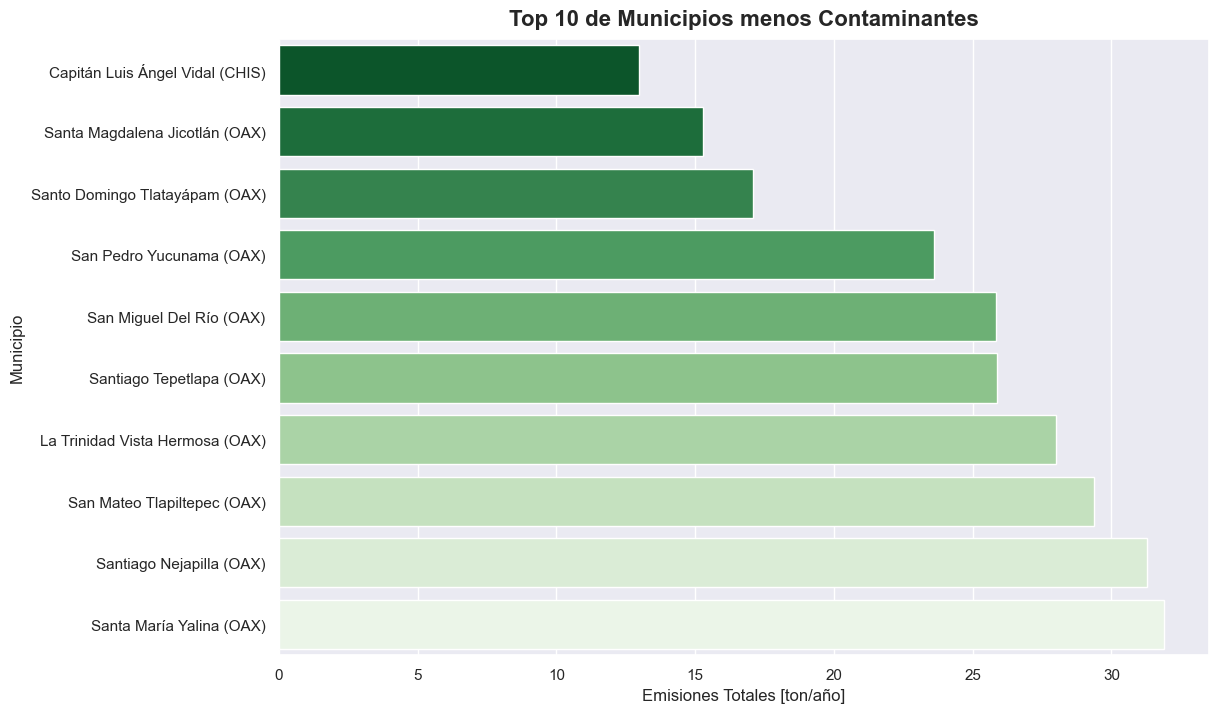

In [112]:
plt.figure(figsize=(12,8))
sns.barplot(
    data=top10_mun_m,
    x='Total_emisiones',
    y='Municipio_Estado',
    palette='Greens_r',
    hue='Municipio_Estado'
)
plt.xlabel('Emisiones Totales [ton/año]')
plt.ylabel('Municipio')
plt.title('Top 10 de Municipios menos Contaminantes',fontsize=16,fontweight='bold',pad=10)
plt.show()

### 2.6 Top 10 por cada Contaminante

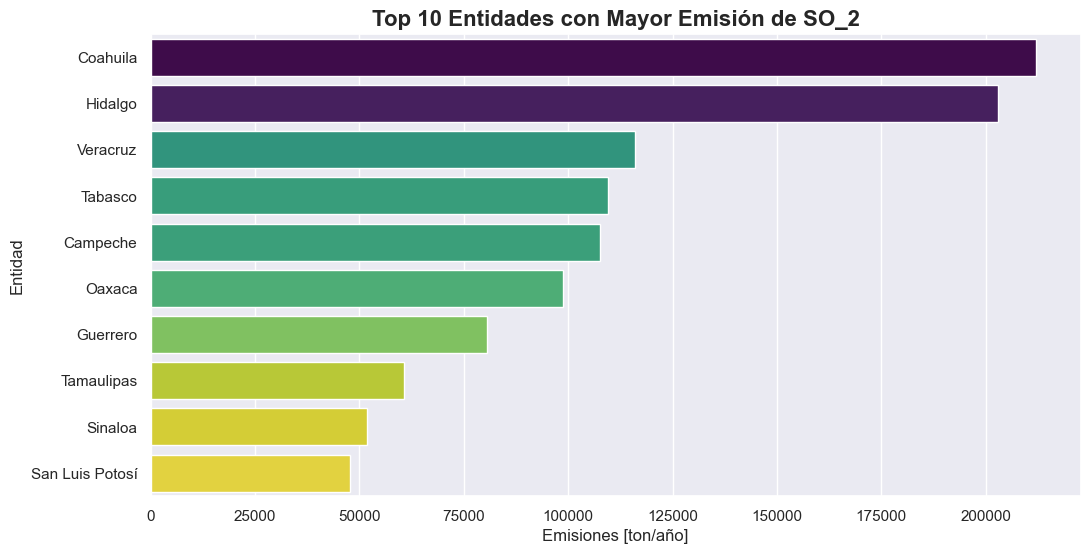

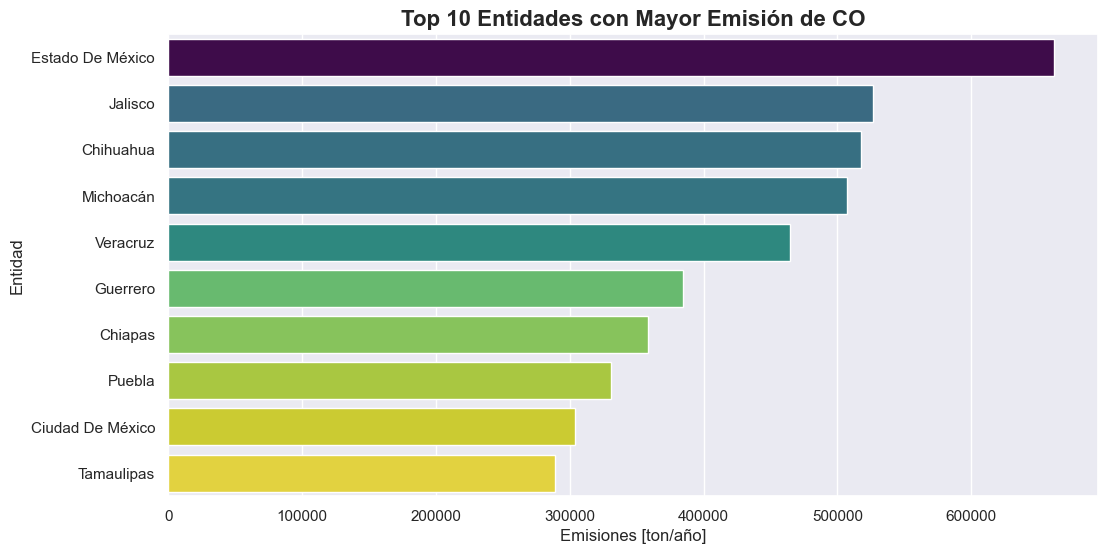

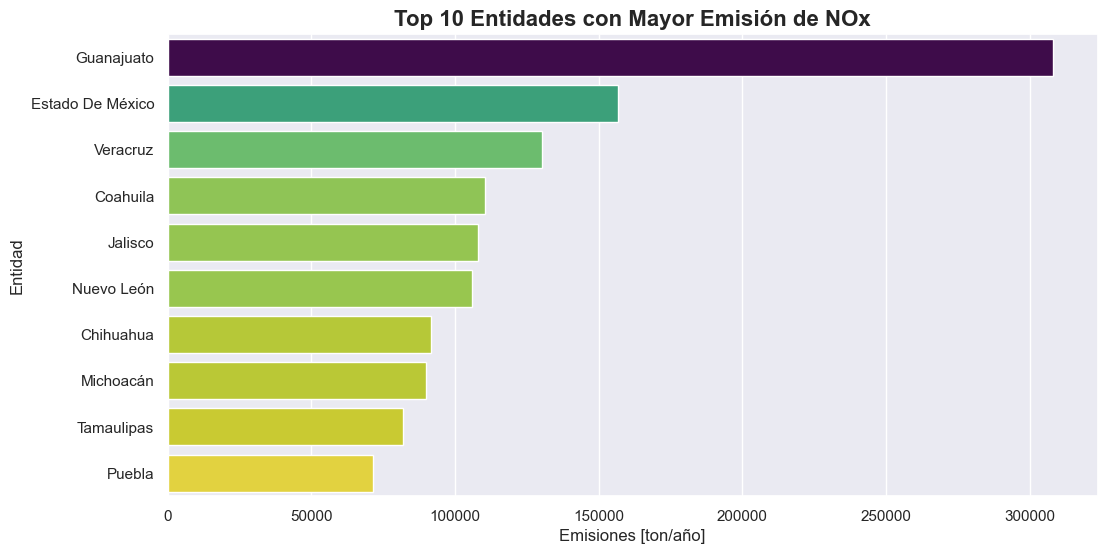

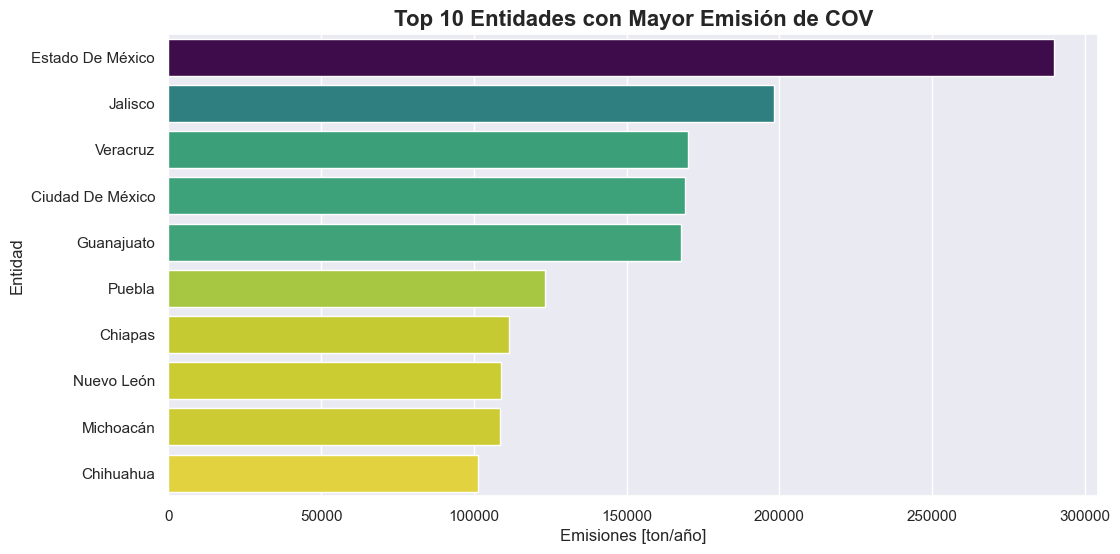

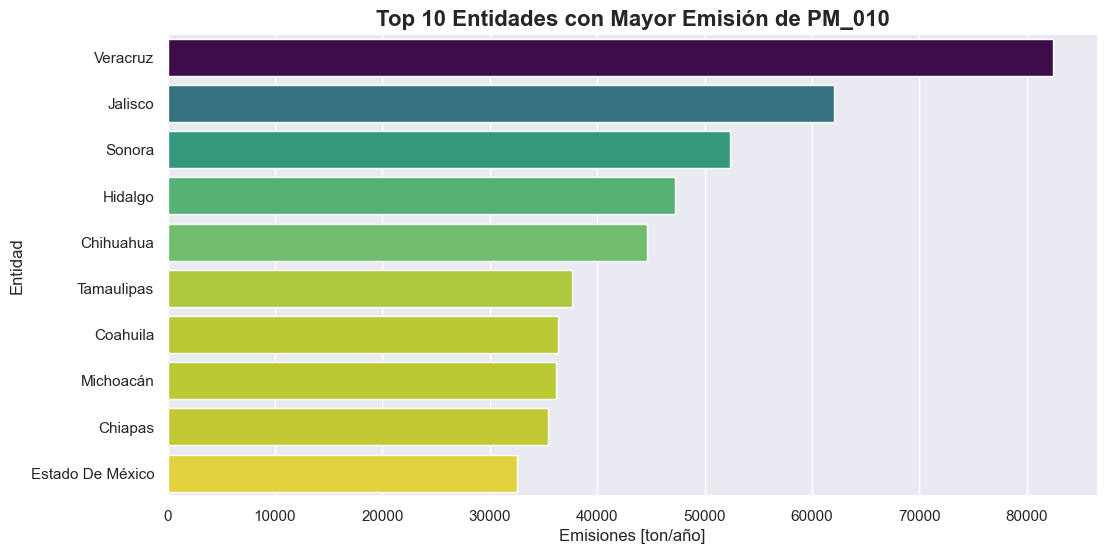

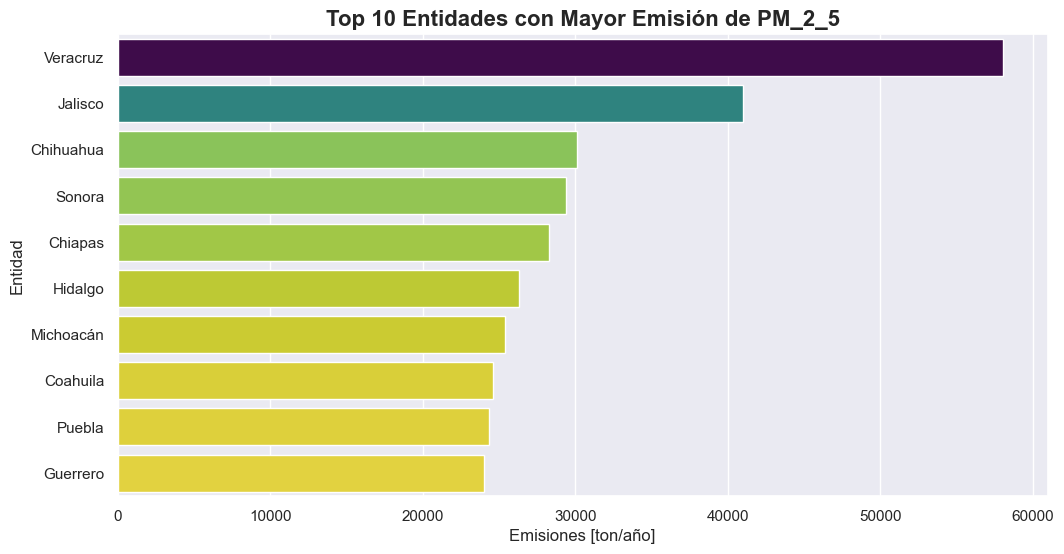

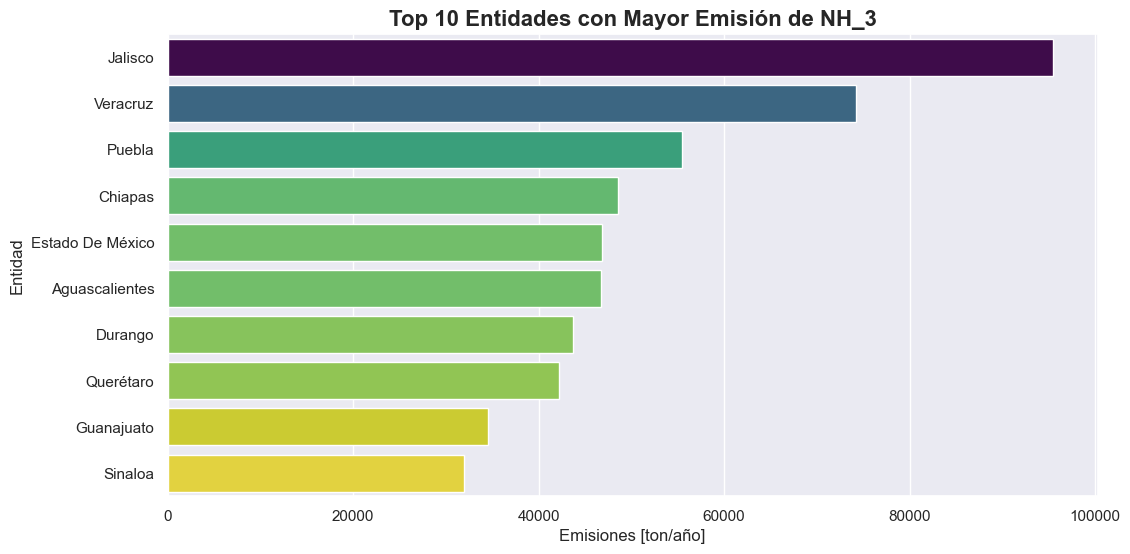

In [113]:
contaminantes = ['SO_2','CO','NOx','COV','PM_010','PM_2_5','NH_3']
df_estados = (
    df_clean.groupby('Entidad_federativa')[contaminantes].sum()
)
for cont in contaminantes:

    top10  = (
        df_estados[[cont]].sort_values(cont,ascending=False).
        head(10).reset_index()
    )

    plt.figure(figsize=(12,6))
    sns.barplot(
        data=top10,
        x=cont,
        y='Entidad_federativa',
        palette='viridis_r',
        hue=cont,
        legend=False
    )
    plt.xlabel('Emisiones [ton/año]')
    plt.ylabel('Entidad')
    plt.title(f'Top 10 Entidades con Mayor Emisión de {cont}',fontsize=16,fontweight='bold')
    plt.show()

### 2.7 Radar Chart por Tipo de Fuente

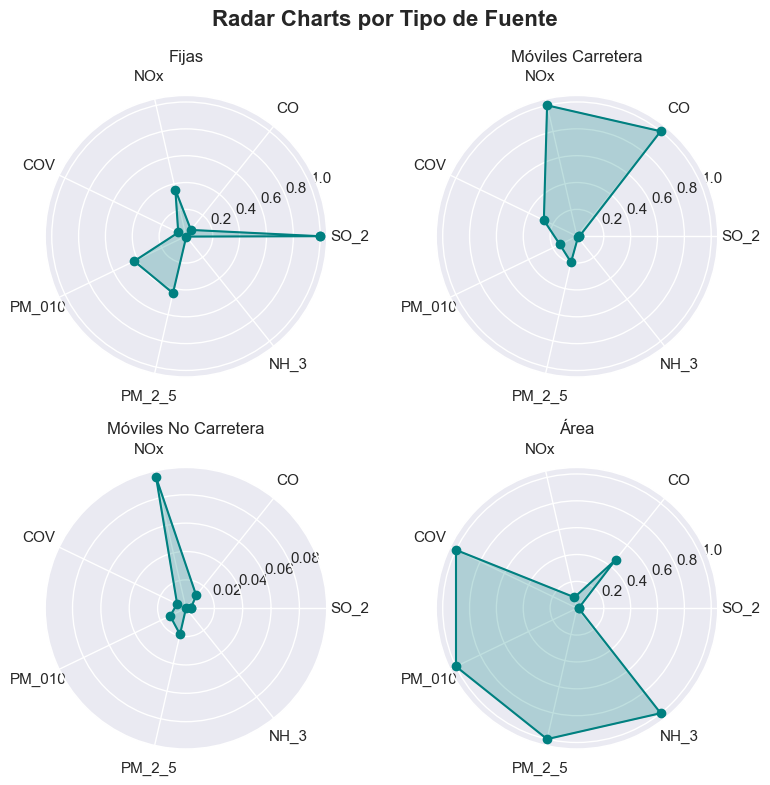

In [114]:
contaminantes = ['SO_2','CO','NOx','COV','PM_010','PM_2_5','NH_3']

df_fuentes = (
    df_clean.groupby('Tipo_de_Fuente')[contaminantes].sum()
)

# Normalizar para que el radar chart sea legible
df_norm = df_fuentes.div(df_fuentes.max())

categories = contaminantes
n = len(categories)

# Preparar ángulos para el radar
angles = np.linspace(0, 2 * np.pi, n, endpoint=False)
angles = np.append(angles, angles[0])

# Número de fuentes y tamaño de la cuadrícula
m = len(df_norm)
cols = int(np.ceil(np.sqrt(m)))
rows = int(np.ceil(m / cols))

fig, axes = plt.subplots(rows, cols, figsize=(4*cols, 4*rows), subplot_kw={'projection': 'polar'})
axes = np.atleast_1d(axes).flatten()

for i, fuente in enumerate(df_norm.index):
    valores = df_norm.loc[fuente].values
    valores = np.append(valores, valores[0])
    ax = axes[i]
    ax.plot(angles, valores, marker='o', color='teal')
    ax.fill(angles, valores, alpha=0.25, color='teal')
    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(categories)
    ax.set_title(fuente, fontsize=12)


plt.suptitle('Radar Charts por Tipo de Fuente', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

### 2.8 Histograma por Contaminante

In [115]:
contaminantes = ['SO_2','CO','NOx','COV','PM_010','PM_2_5','NH_3']

for col in contaminantes:
    df_clean[f'{col}_log'] = np.log1p(df_clean[col])

C:\Users\Andre\AppData\Local\Temp\ipykernel_22188\4140420086.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_clean[f'{col}_log'] = np.log1p(df_clean[col])
C:\Users\Andre\AppData\Local\Temp\ipykernel_22188\4140420086.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_clean[f'{col}_log'] = np.log1p(df_clean[col])
C:\Users\Andre\AppData\Local\Temp\ipykernel_22188\4140420086.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,co

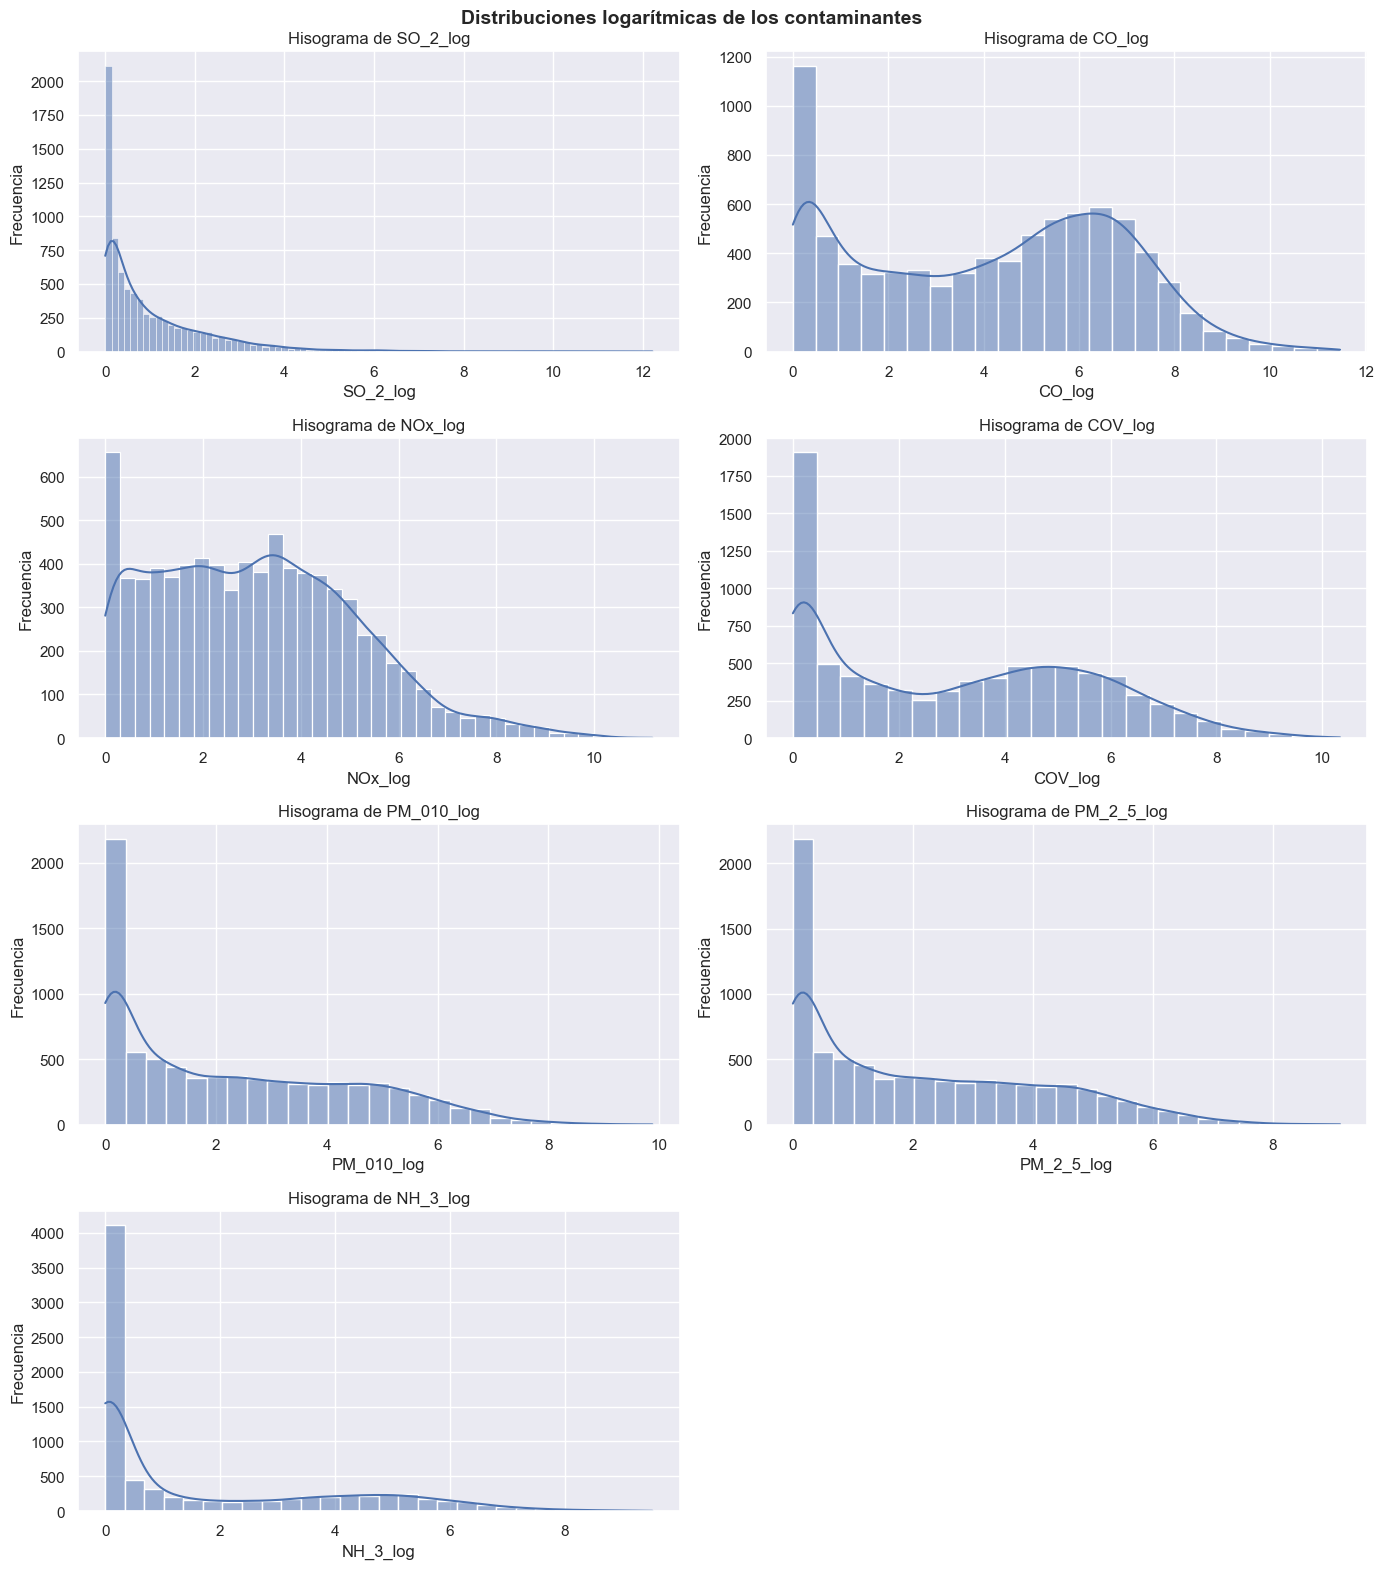

In [116]:
contaminantes = ['SO_2','CO','NOx','COV','PM_010','PM_2_5','NH_3']
log_cols = [f"{c}_log" for c in contaminantes]

# Crear figura
fig, axes = plt.subplots(4, 2, figsize=(14, 16))
axes = axes.flatten()

for i, col in enumerate(log_cols):
    sns.histplot(df_clean[col],ax=axes[i],kde=True)
    axes[i].set_title(f'Hisograma de {col}')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Frecuencia')

# Eliminar Subplot vacío
fig.delaxes(axes[-1])
plt.suptitle('Distribuciones logarítmicas de los contaminantes',fontsize=14,fontweight='bold')
plt.tight_layout()
plt.show()

### 2.9 Violinplot por Tipo de Fuente


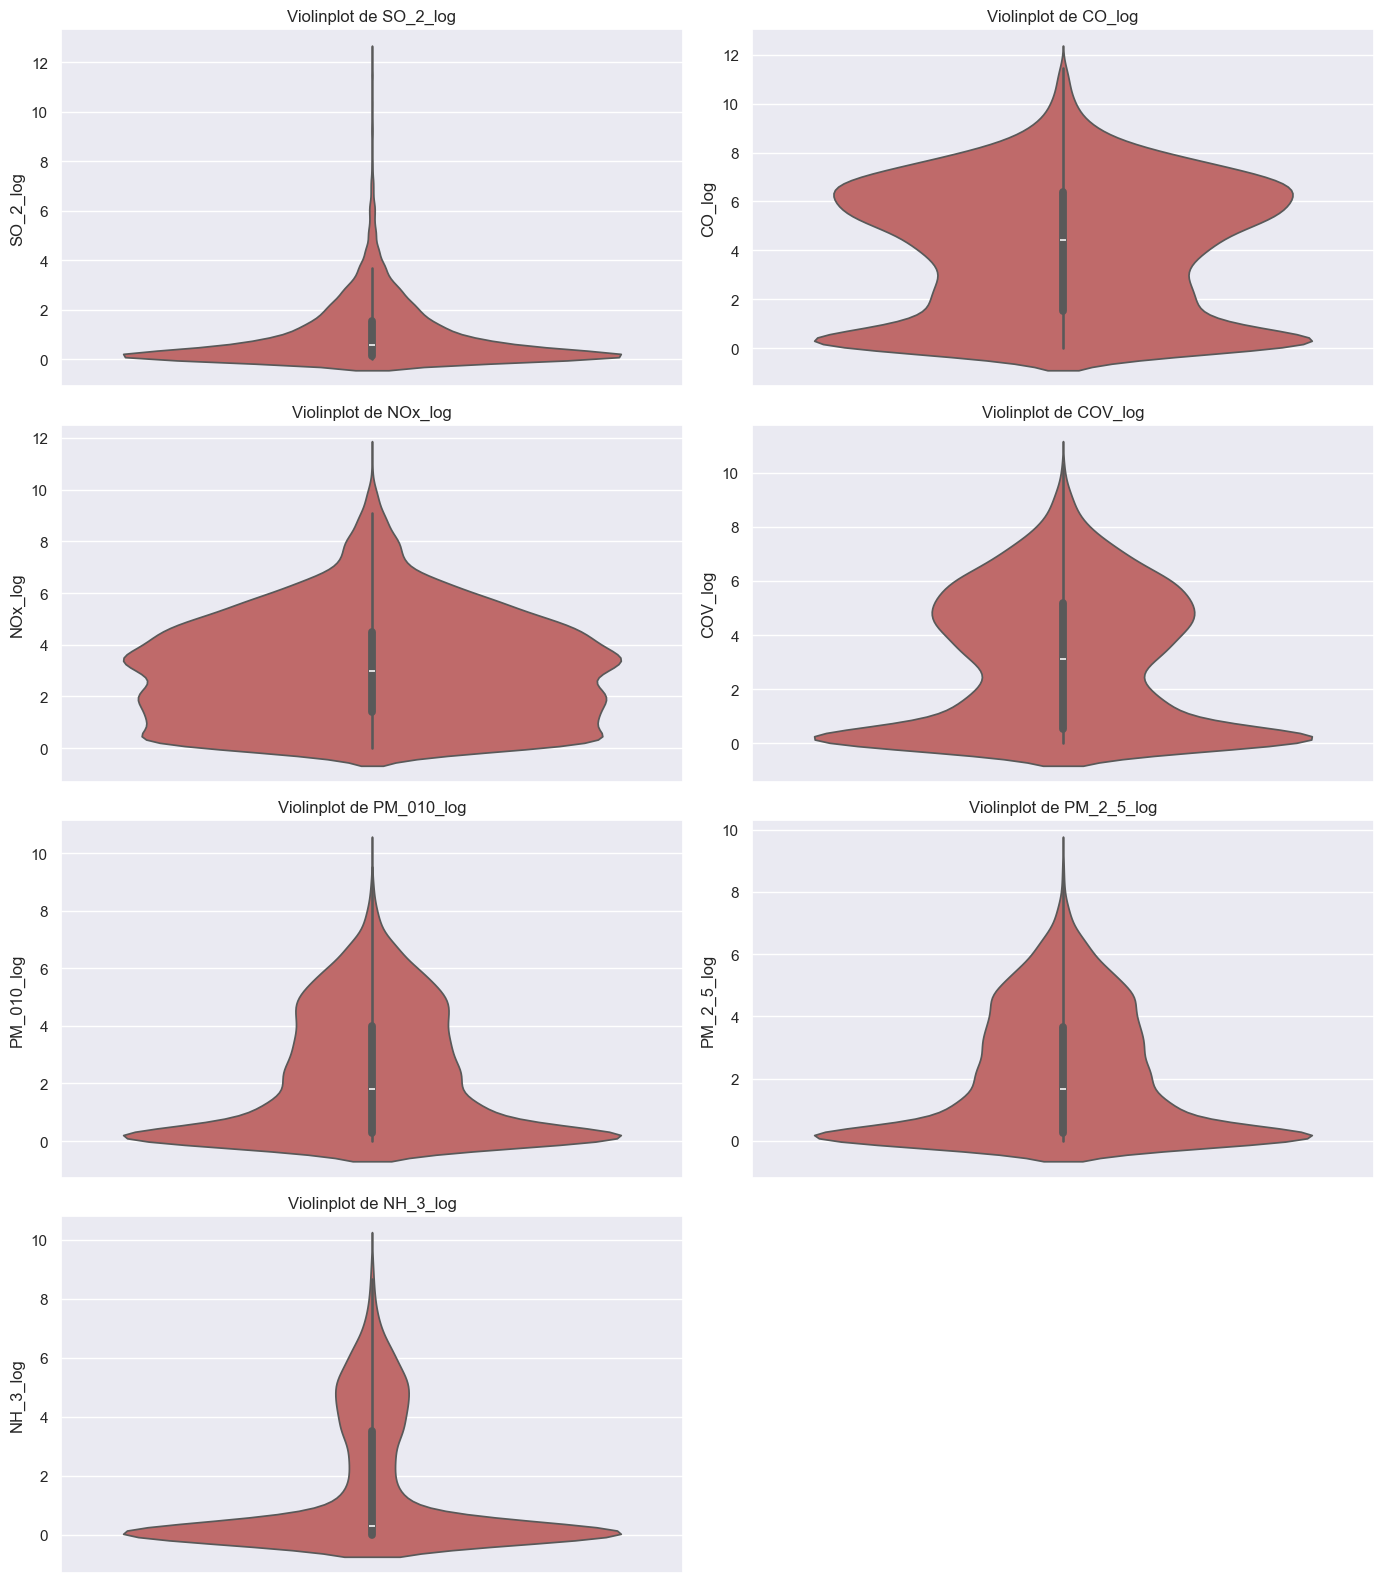

In [117]:
contaminantes = ['SO_2','CO','NOx','COV','PM_010','PM_2_5','NH_3']
log_cols = [f"{c}_log" for c in contaminantes] 
fig, axes = plt.subplots(4, 2, figsize=(14, 16))
axes = axes.flatten()

for i, col in enumerate(log_cols):
    sns.violinplot(y=df_clean[col], ax=axes[i],color='indianred')
    axes[i].set_title(f"Violinplot de {col}")

fig.delaxes(axes[-1])
plt.tight_layout()
plt.show()


### 2.10 Boxplot: Entidad Federativs vs Contaminantes

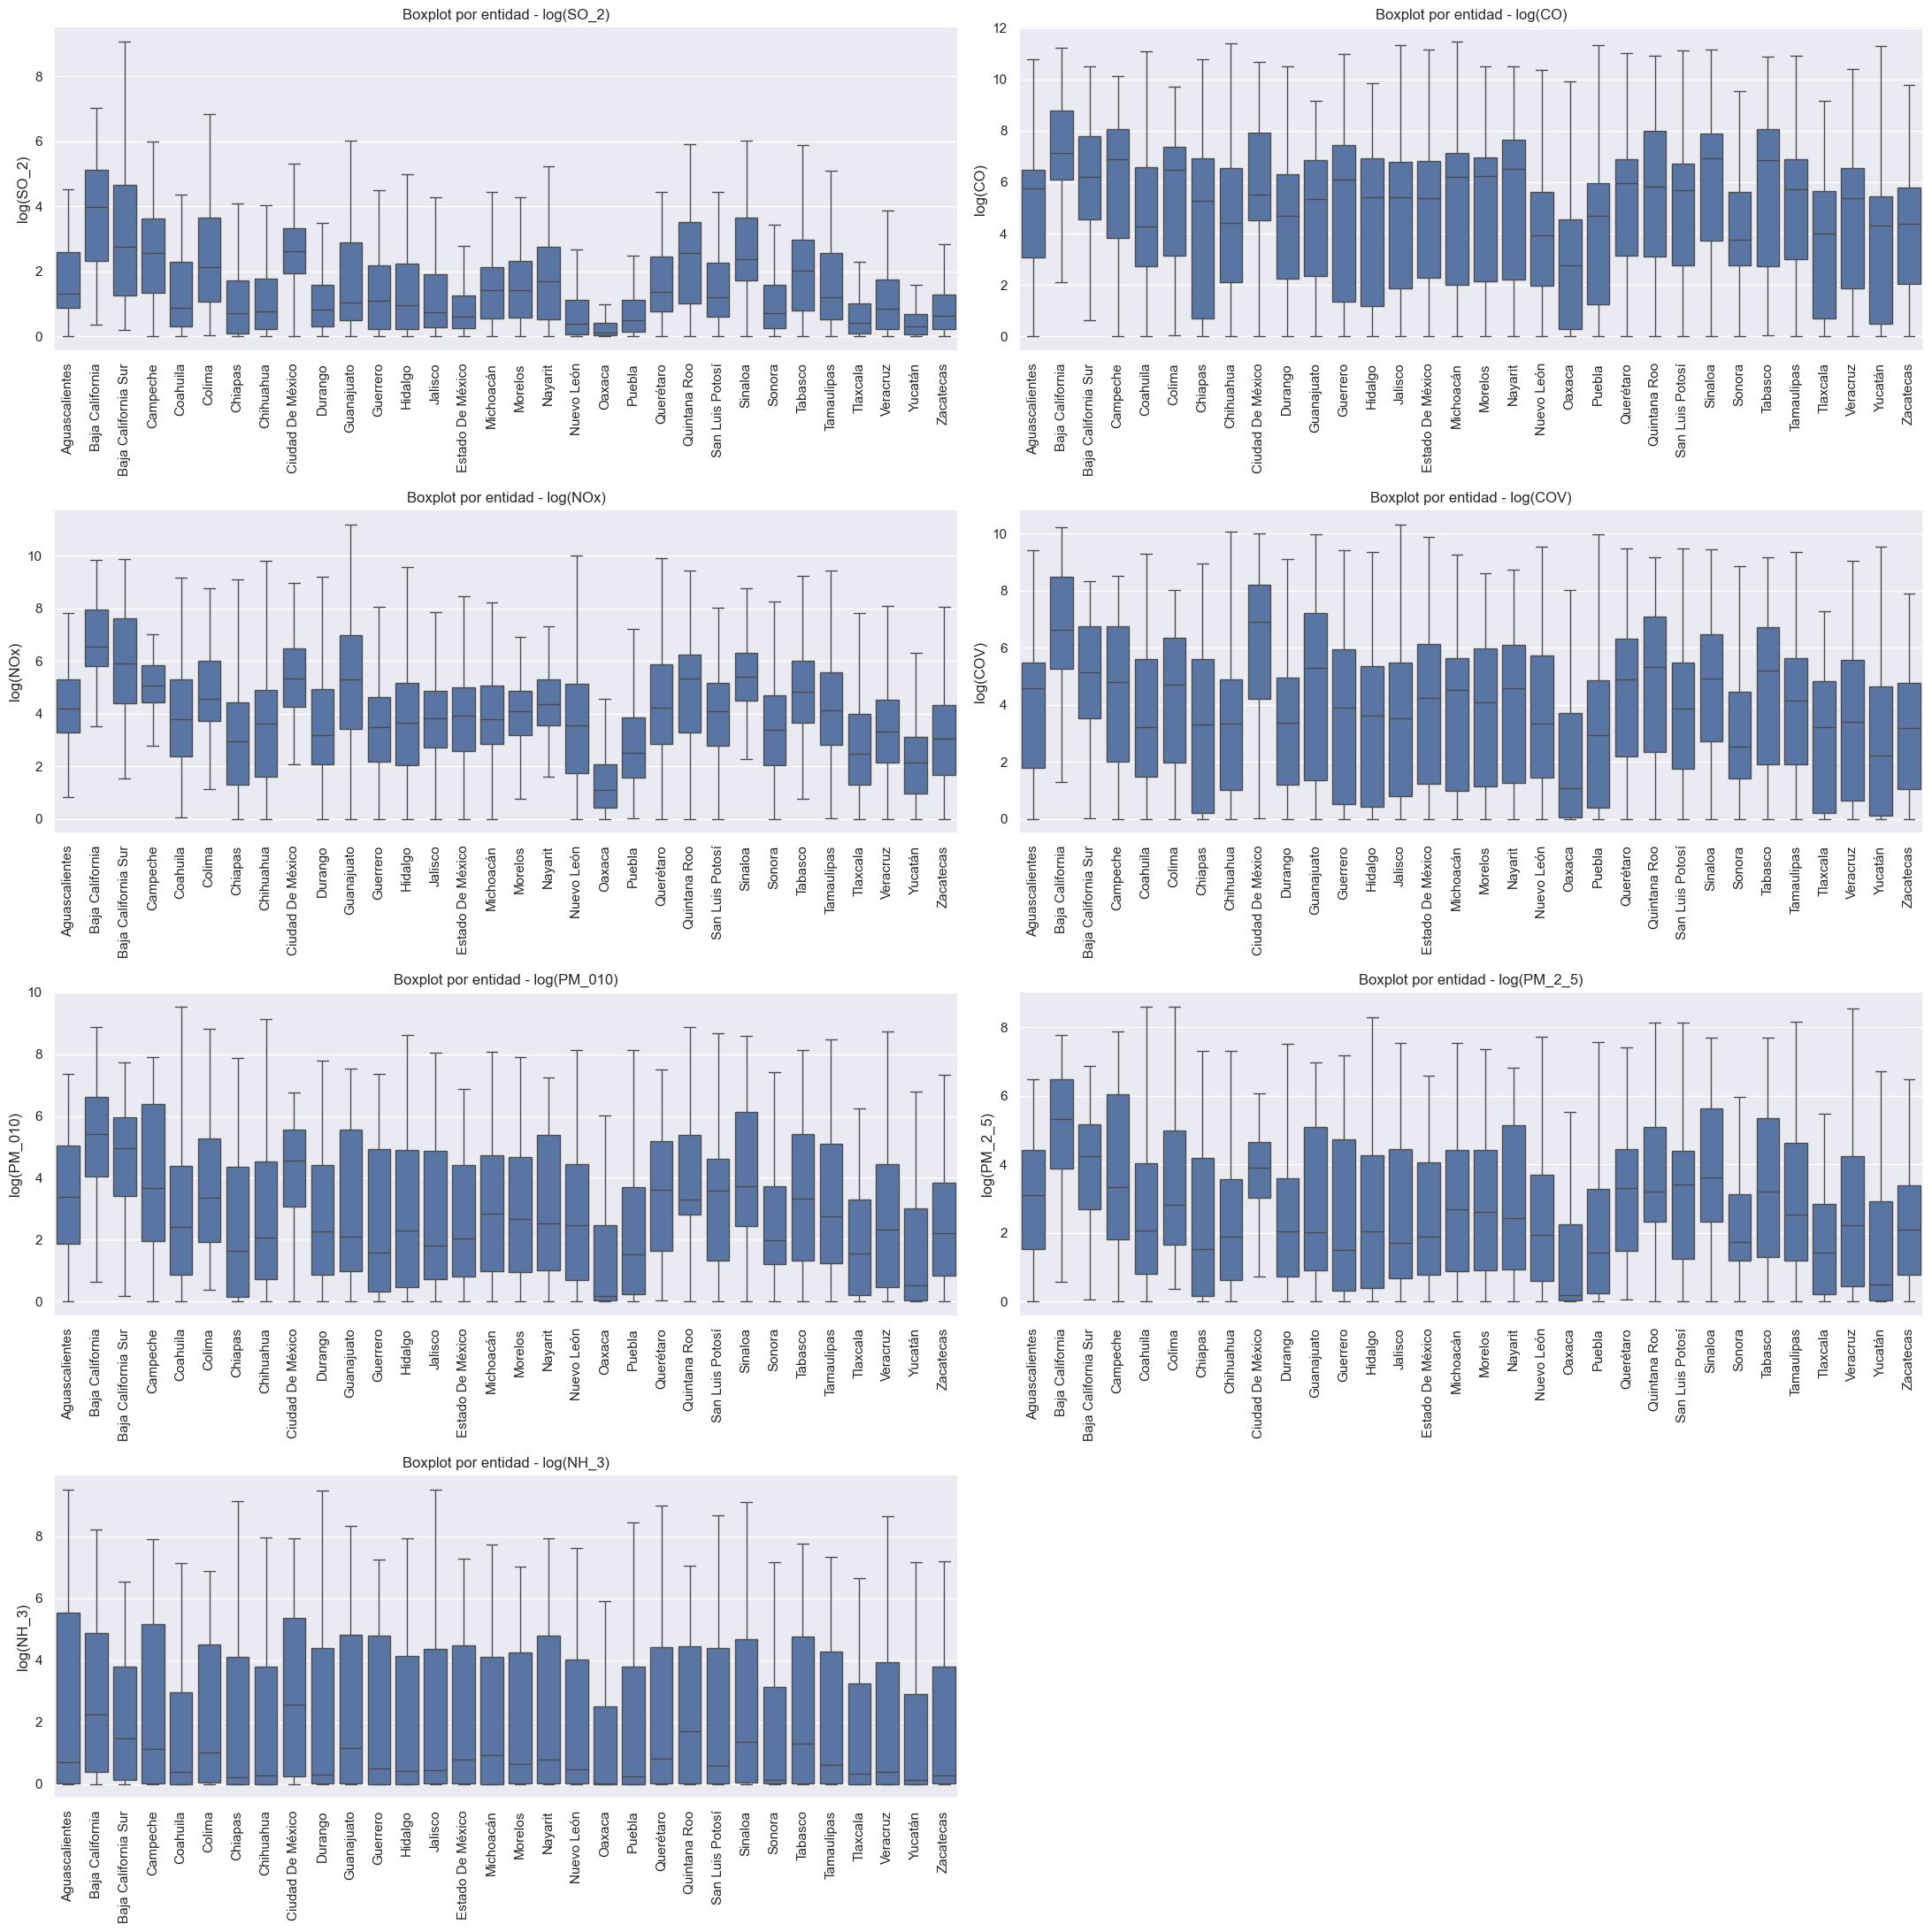

In [118]:
contaminantes = ['SO_2','CO','NOx','COV','PM_010','PM_2_5','NH_3']
log_cols = [f"{c}_log" for c in contaminantes]

fig, axes = plt.subplots(4, 2, figsize=(22, 22))
axes = axes.flatten()

for i,(col,log_col) in enumerate(zip(contaminantes,log_cols)):
    sns.boxplot(
        data=df_clean,
        x='Entidad_federativa',
        y=log_col,
        ax=axes[i],
        showfliers=False
    )
    axes[i].set_title(f'Boxplot por entidad - log({col})')
    axes[i].set_xlabel('')
    axes[i].set_ylabel(f'log({col})')
    axes[i].tick_params(axis='x',rotation=90)

# Eliminar el subplot vacío
fig.delaxes(axes[-1])

plt.tight_layout()
plt.show()

### 2.11 Heatmap de contaminantes


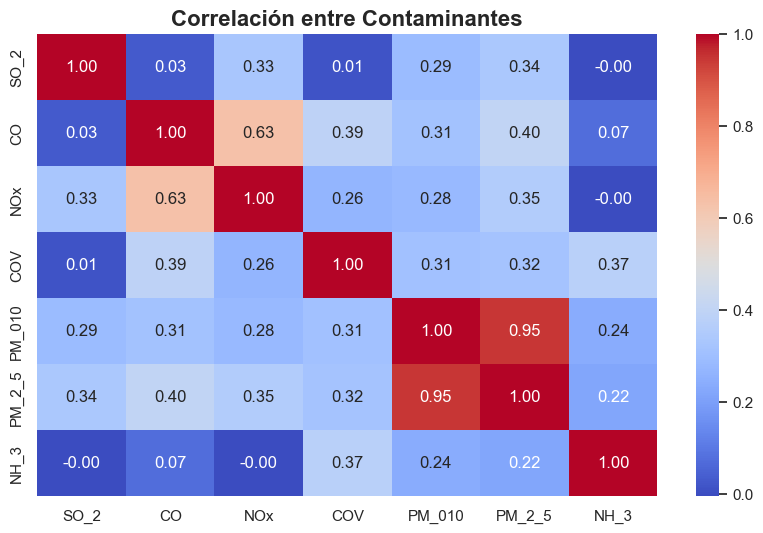

In [119]:
contaminantes = ['SO_2','CO','NOx','COV','PM_010','PM_2_5','NH_3']
corr = df_clean[contaminantes].corr()
plt.figure(figsize=(10,6))
sns.heatmap(
    corr,
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)
plt.title('Correlación entre Contaminantes',fontsize=16,fontweight='bold')
plt.show()

### 2.12 Análisis de NOx

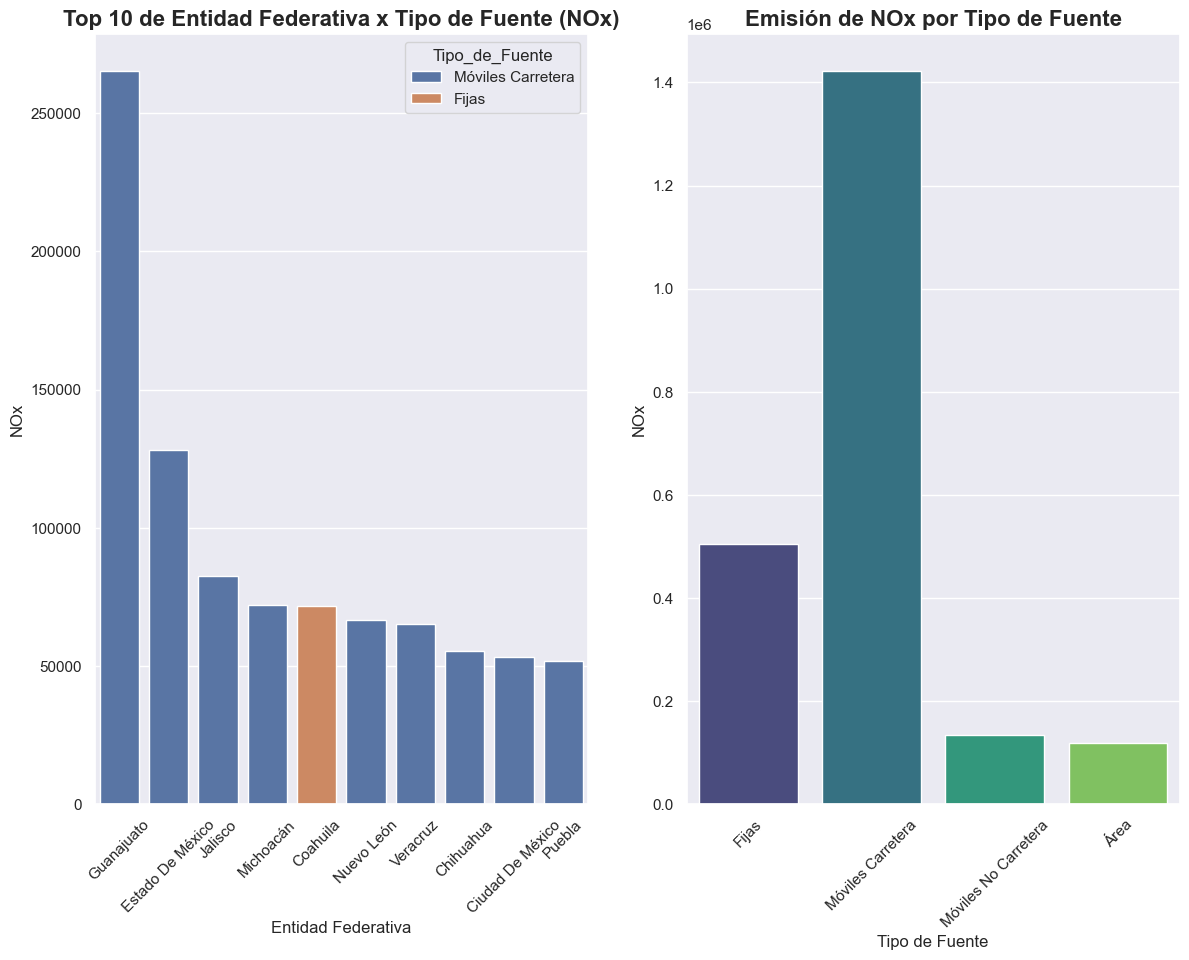

In [120]:
df_top_nox = (
    df_clean.groupby(['Entidad_federativa','Tipo_de_Fuente'])['NOx'].sum().
    reset_index().sort_values('NOx',ascending=False)
)
df_top_c= (
    df_clean.groupby('Tipo_de_Fuente')['NOx'].sum().
    reset_index()
)

# Subplots
fig,axes = plt.subplots(1,2,figsize=(14,10),sharey=False)

# Top 10 de Entidad Federativa x Tipo de Fuente
sns.barplot(
    data=df_top_nox.head(10),
    x='Entidad_federativa',
    y='NOx',
    hue='Tipo_de_Fuente',
    ax=axes[0]
)
axes[0].tick_params(axis='x',rotation=45)
axes[0].set_xlabel('Entidad Federativa')
axes[0].set_title('Top 10 de Entidad Federativa x Tipo de Fuente (NOx)',fontsize=16,fontweight='bold')

#
sns.barplot(
    data=df_top_c,
    x='Tipo_de_Fuente',
    y='NOx',
    palette='viridis',
    hue='Tipo_de_Fuente',
    ax=axes[1]
)
axes[1].tick_params(axis='x',rotation=45)
axes[1].set_xlabel('Tipo de Fuente')
axes[1].set_title('Emisión de NOx por Tipo de Fuente',fontsize=16,fontweight='bold')
plt.show()

### 2.13 Análisis de PM2.5

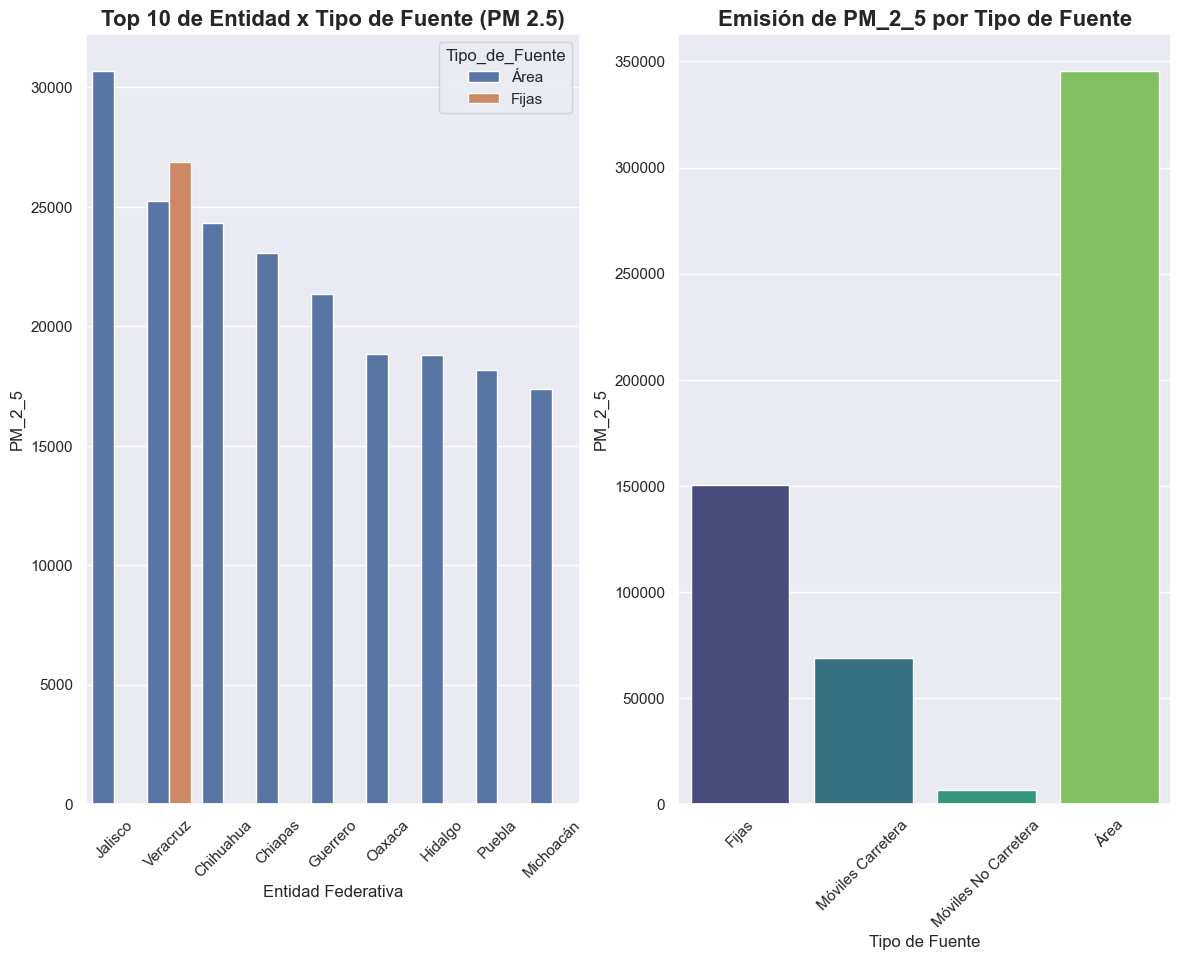

In [121]:
df_top_pm25 = (
    df_clean.groupby(['Entidad_federativa','Tipo_de_Fuente'])['PM_2_5'].sum().
    reset_index().sort_values('PM_2_5',ascending=False)
)
df_top_fuente_pm25= (
    df_clean.groupby('Tipo_de_Fuente')['PM_2_5'].sum().
    reset_index()
)

# Subplots
fig,axes = plt.subplots(1,2,figsize=(14,10),sharey=False)

# Top 10 de Entidad Federativa x Tipo de Fuente
sns.barplot(
    data=df_top_pm25.head(10),
    x='Entidad_federativa',
    y='PM_2_5',
    hue='Tipo_de_Fuente',
    ax=axes[0]
)
axes[0].tick_params(axis='x',rotation=45)
axes[0].set_xlabel('Entidad Federativa')
axes[0].set_title('Top 10 de Entidad x Tipo de Fuente (PM 2.5)',fontsize=16,fontweight='bold')

#
sns.barplot(
    data=df_top_fuente_pm25,
    x='Tipo_de_Fuente',
    y='PM_2_5',
    palette='viridis',
    hue='Tipo_de_Fuente',
    ax=axes[1]
)
axes[1].tick_params(axis='x',rotation=45)
axes[1].set_xlabel('Tipo de Fuente')
axes[1].set_title('Emisión de PM_2_5 por Tipo de Fuente',fontsize=16,fontweight='bold')
plt.show()

### 2.14 Análisis PM10

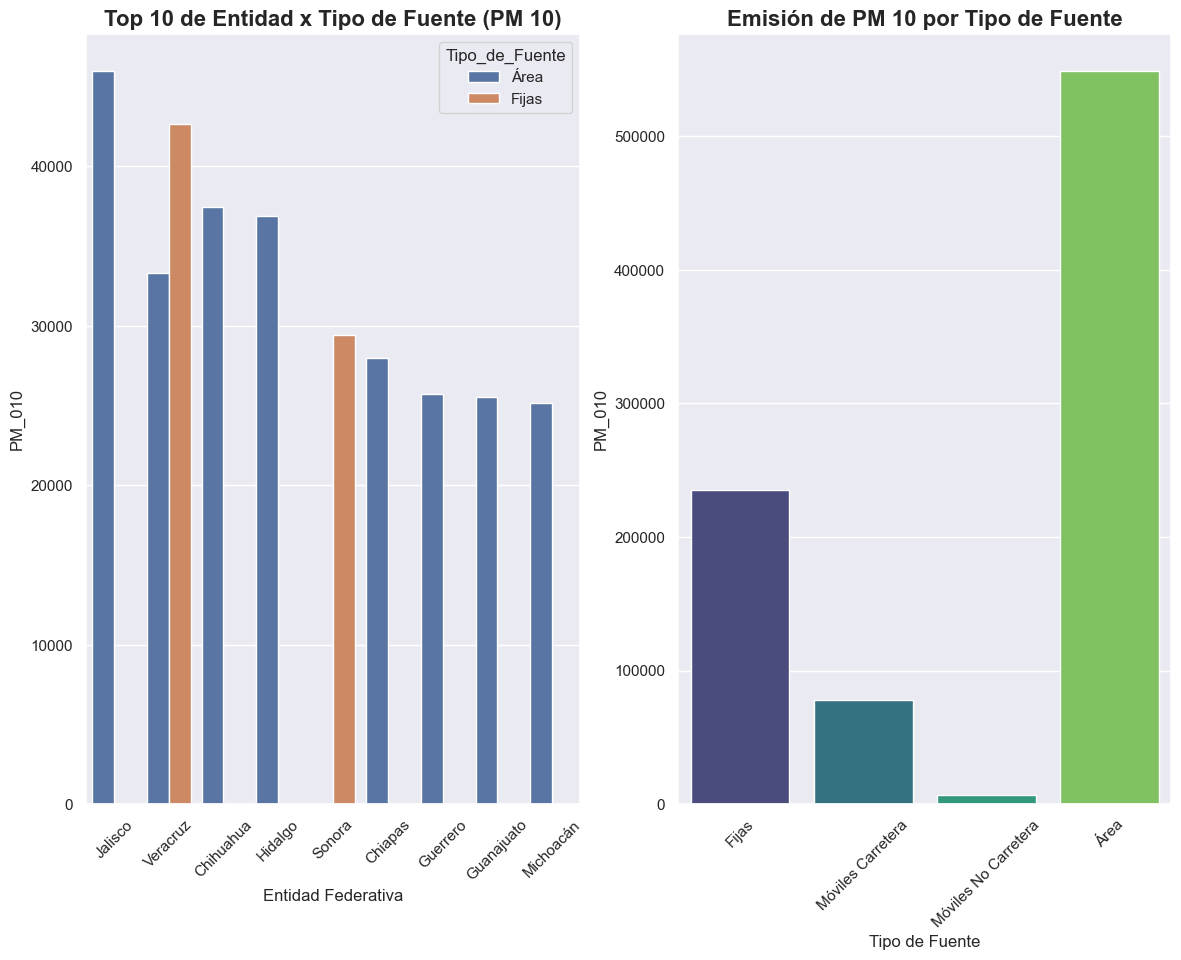

In [122]:
df_top_pm10 = (
    df_clean.groupby(['Entidad_federativa','Tipo_de_Fuente'])['PM_010'].sum().
    reset_index().sort_values('PM_010',ascending=False)
)
df_top_fuente_pm10= (
    df_clean.groupby('Tipo_de_Fuente')['PM_010'].sum().
    reset_index()
)

# Subplots
fig,axes = plt.subplots(1,2,figsize=(14,10),sharey=False)

# Top 10 de Entidad Federativa x Tipo de Fuente
sns.barplot(
    data=df_top_pm10.head(10),
    x='Entidad_federativa',
    y='PM_010',
    hue='Tipo_de_Fuente',
    ax=axes[0]
)
axes[0].tick_params(axis='x',rotation=45)
axes[0].set_xlabel('Entidad Federativa')
axes[0].set_title('Top 10 de Entidad x Tipo de Fuente (PM 10)',fontsize=16,fontweight='bold')

#
sns.barplot(
    data=df_top_fuente_pm10,
    x='Tipo_de_Fuente',
    y='PM_010',
    palette='viridis',
    hue='Tipo_de_Fuente',
    ax=axes[1]
)
axes[1].tick_params(axis='x',rotation=45)
axes[1].set_xlabel('Tipo de Fuente')
axes[1].set_title('Emisión de PM 10 por Tipo de Fuente',fontsize=16,fontweight='bold')
plt.show()

### 2.15 Análisis SO2

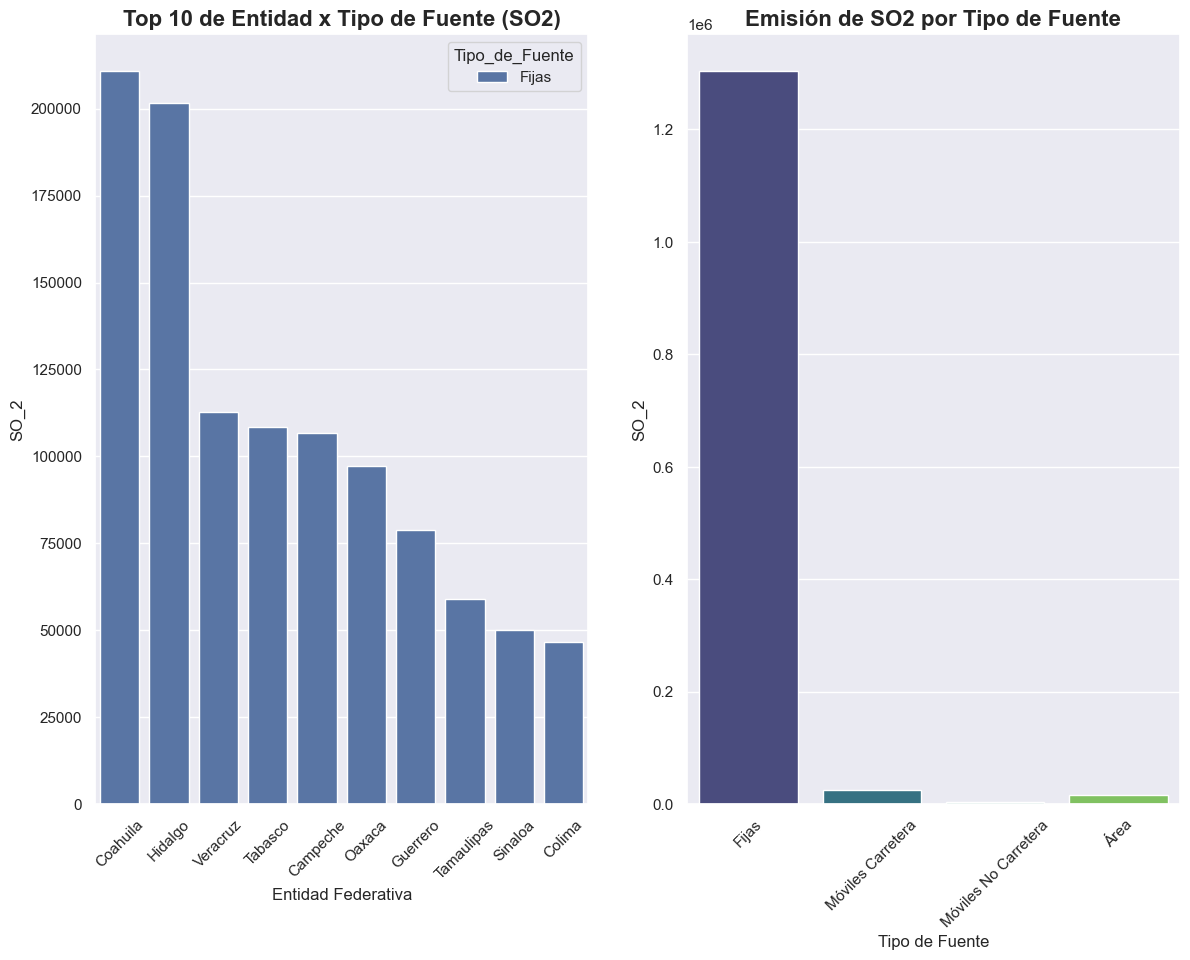

In [123]:
df_top_so2 = (
    df_clean.groupby(['Entidad_federativa','Tipo_de_Fuente'])['SO_2'].sum().
    reset_index().sort_values('SO_2',ascending=False)
)
df_top_fuente_so2= (
    df_clean.groupby('Tipo_de_Fuente')['SO_2'].sum().
    reset_index()
)

# Subplots
fig,axes = plt.subplots(1,2,figsize=(14,10),sharey=False)

# Top 10 de Entidad Federativa x Tipo de Fuente
sns.barplot(
    data=df_top_so2.head(10),
    x='Entidad_federativa',
    y='SO_2',
    hue='Tipo_de_Fuente',
    ax=axes[0]
)
axes[0].tick_params(axis='x',rotation=45)
axes[0].set_xlabel('Entidad Federativa')
axes[0].set_title('Top 10 de Entidad x Tipo de Fuente (SO2)',fontsize=16,fontweight='bold')

#
sns.barplot(
    data=df_top_fuente_so2,
    x='Tipo_de_Fuente',
    y='SO_2',
    palette='viridis',
    hue='Tipo_de_Fuente',
    ax=axes[1]
)
axes[1].tick_params(axis='x',rotation=45)
axes[1].set_xlabel('Tipo de Fuente')
axes[1].set_title('Emisión de SO2 por Tipo de Fuente',fontsize=16,fontweight='bold')
plt.show()

In [124]:
df_clean.columns

Index(['Entidad_federativa', 'Municipio', 'Tipo_de_Fuente', 'SO_2', 'CO',
       'NOx', 'COV', 'PM_010', 'PM_2_5', 'NH_3', 'Abrev', 'Municipio_Estado',
       'SO_2_log', 'CO_log', 'NOx_log', 'COV_log', 'PM_010_log', 'PM_2_5_log',
       'NH_3_log'],
      dtype='object')

### 2.16 Comparaciones por tipo de fuente

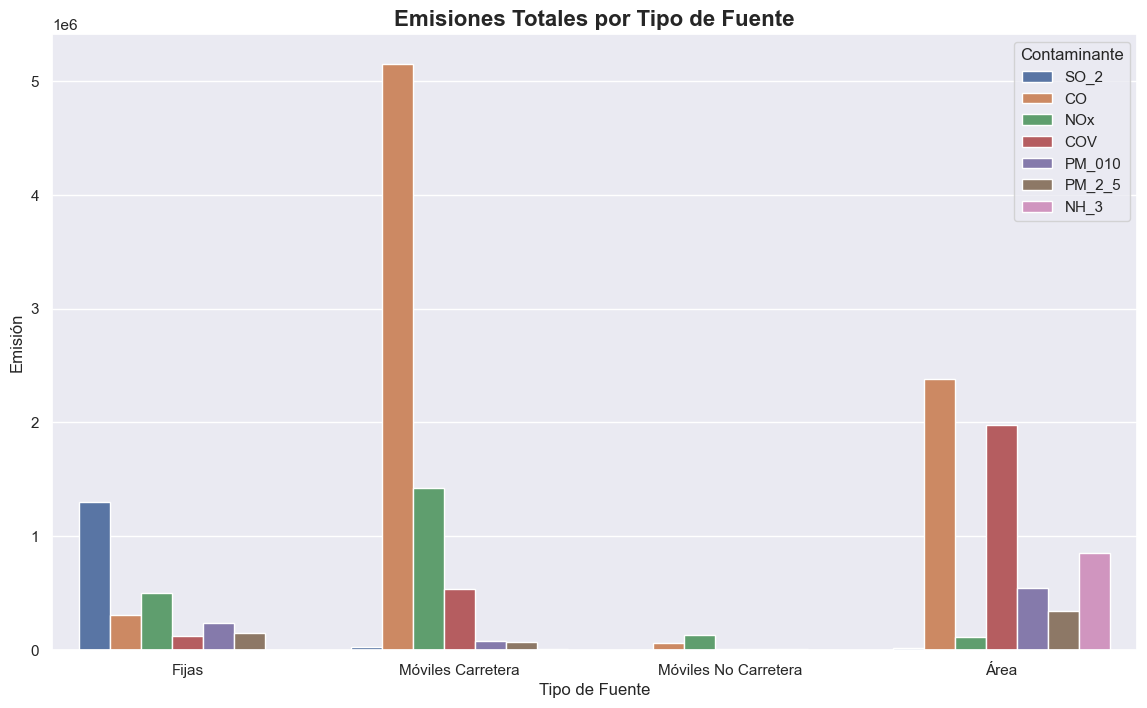

In [125]:
contaminantes = ['SO_2','CO','NOx','COV','PM_010','PM_2_5','NH_3']

df_fuentes = (
    df_clean.groupby('Tipo_de_Fuente')[contaminantes].sum().reset_index()
)
df_melt = df_fuentes.melt(id_vars='Tipo_de_Fuente',var_name='Contaminante',value_name='Emisión')

plt.figure(figsize=(14,8))
sns.barplot(
    data=df_melt,
    x='Tipo_de_Fuente',
    y='Emisión',
    hue='Contaminante'
)
plt.xlabel('Tipo de Fuente')
plt.title('Emisiones Totales por Tipo de Fuente',fontsize=16,fontweight='bold')
plt.show()

### 2.17 Gráficas de burbujas

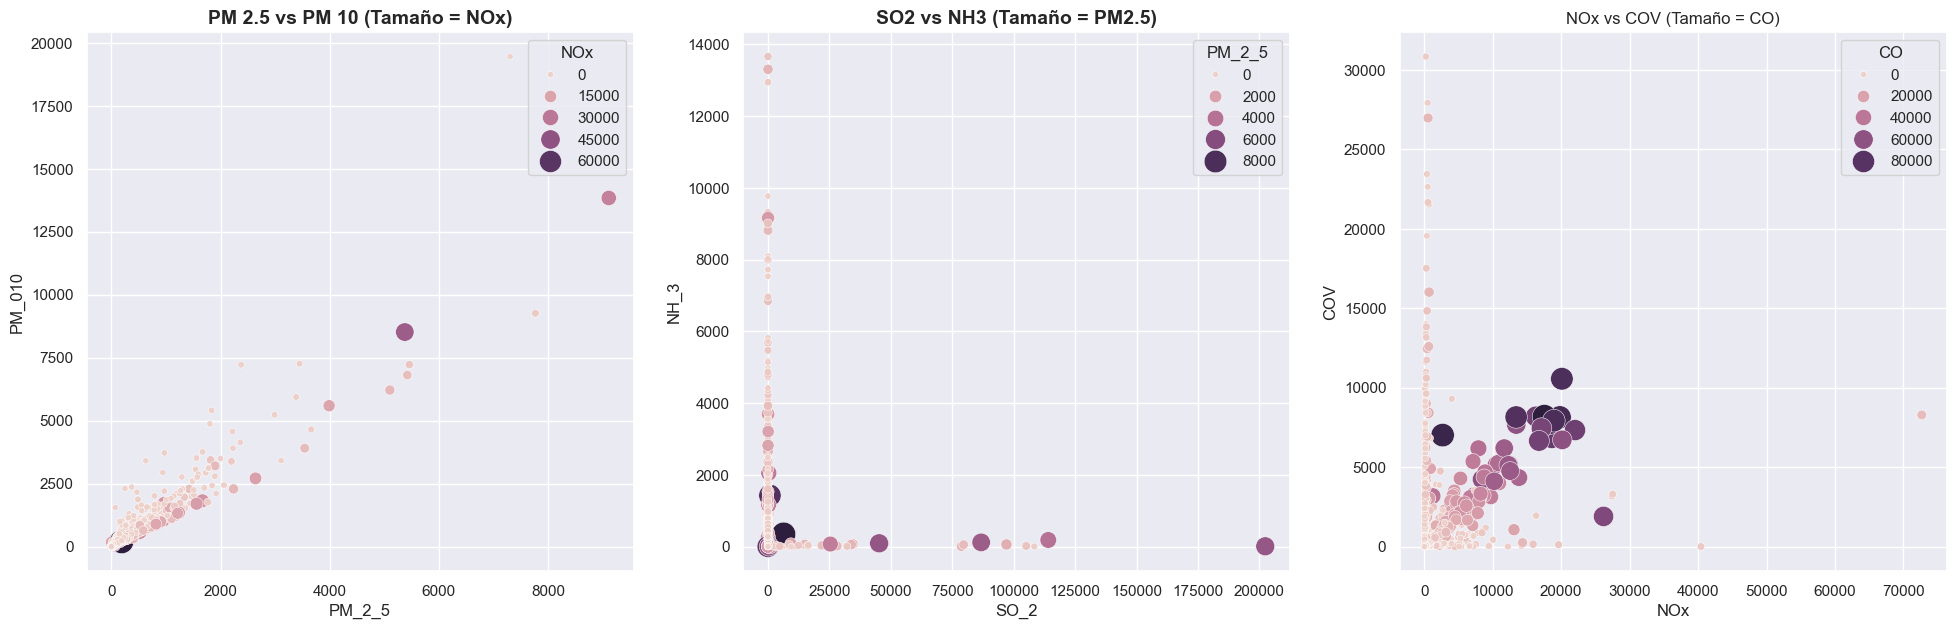

In [126]:
fig,axes = plt.subplots(1,3,figsize=(24,7))

# PM2.5 vs PM10 (tamaño NOx)
sns.scatterplot(
    data=df_clean,
    x='PM_2_5',
    y='PM_010',
    size='NOx',
    hue='NOx',
    sizes=(20,300),
    ax=axes[0]
)
axes[0].set_title('PM 2.5 vs PM 10 (Tamaño = NOx)',fontsize=14,fontweight='bold')

# SO2 vs NH3 (tamaño PM2.5)
sns.scatterplot(
    data=df_clean,
    x='SO_2',
    y='NH_3',
    size='PM_2_5',
    hue='PM_2_5',
    sizes=(20,300),
    ax=axes[1]
)
axes[1].set_title('SO2 vs NH3 (Tamaño = PM2.5)',fontsize=14,fontweight='bold')

# NOx vs COV (tamaño CO)
sns.scatterplot(
    data=df_clean,
    x='NOx',
    y='COV',
    size='CO',
    hue='CO',
    sizes=(20,300),
    ax=axes[2]
)
axes[2].set_title('NOx vs COV (Tamaño = CO)')
plt.show()

### 2.18 Boxplot por Tipo de Fuente

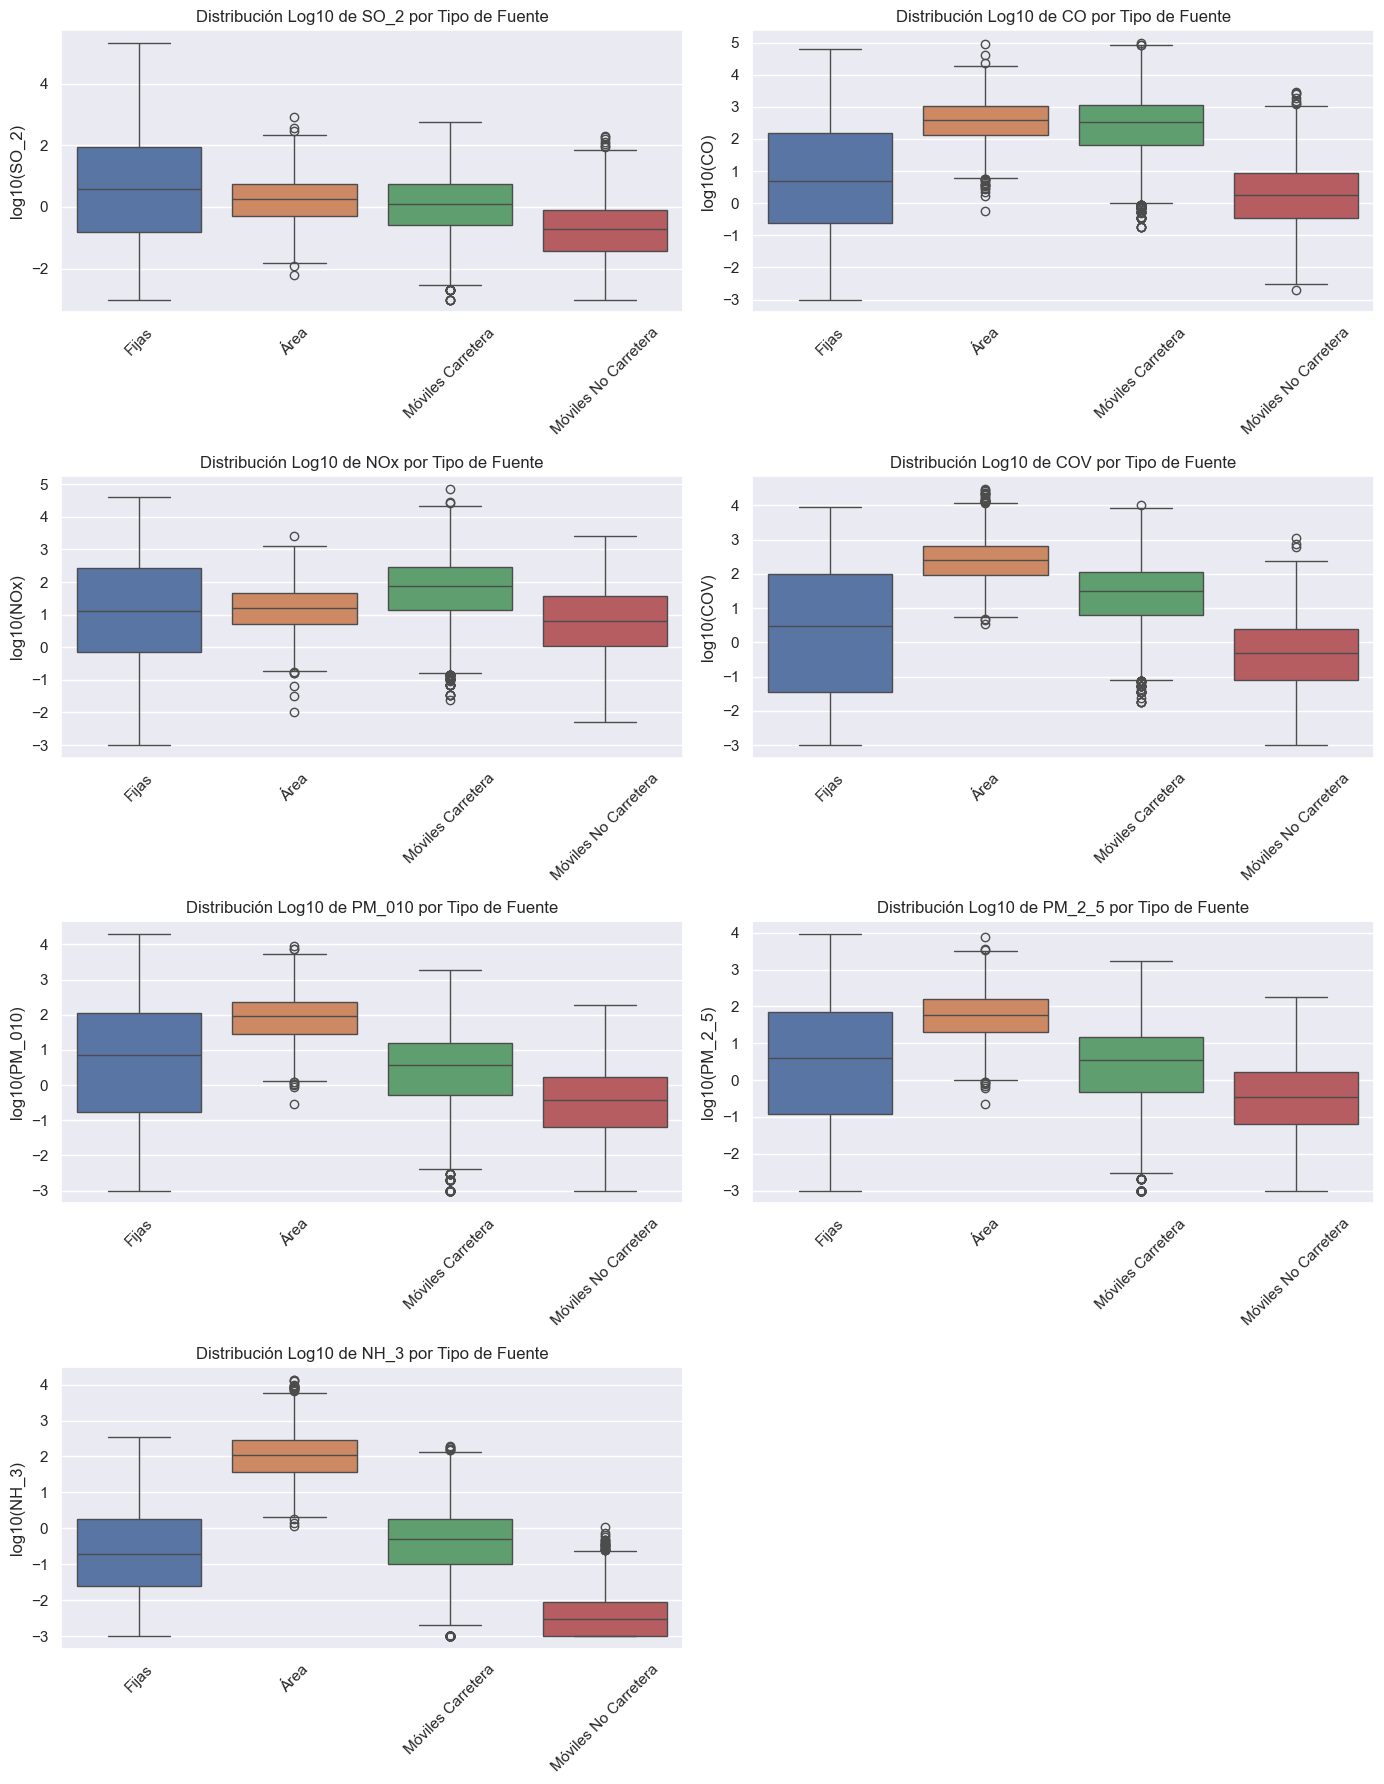

In [130]:
contaminantes = ['SO_2','CO','NOx','COV','PM_010','PM_2_5','NH_3']

fig,axes = plt.subplots(nrows=4,ncols=2,figsize=(14,18))
axes=axes.flatten()
for i,cont in enumerate(contaminantes):
    ax = axes[i]

    df_plot = df_clean.copy()
    df_plot[cont] = np.log10(df_plot[cont].replace(0,np.nan))

    sns.boxplot(
        data=df_plot,
        x='Tipo_de_Fuente',
        y=cont,
        hue='Tipo_de_Fuente',
        ax=ax
    )
    ax.set_title(f"Distribución Log10 de {cont} por Tipo de Fuente")
    ax.set_xlabel("")
    ax.set_ylabel(f"log10({cont})")
    ax.tick_params(axis='x', rotation=45)
# Eliminar el subplot vacío
fig.delaxes(axes[-1])
plt.tight_layout()
plt.show()

### 2.19 Violinplots por Tipo de Fuente

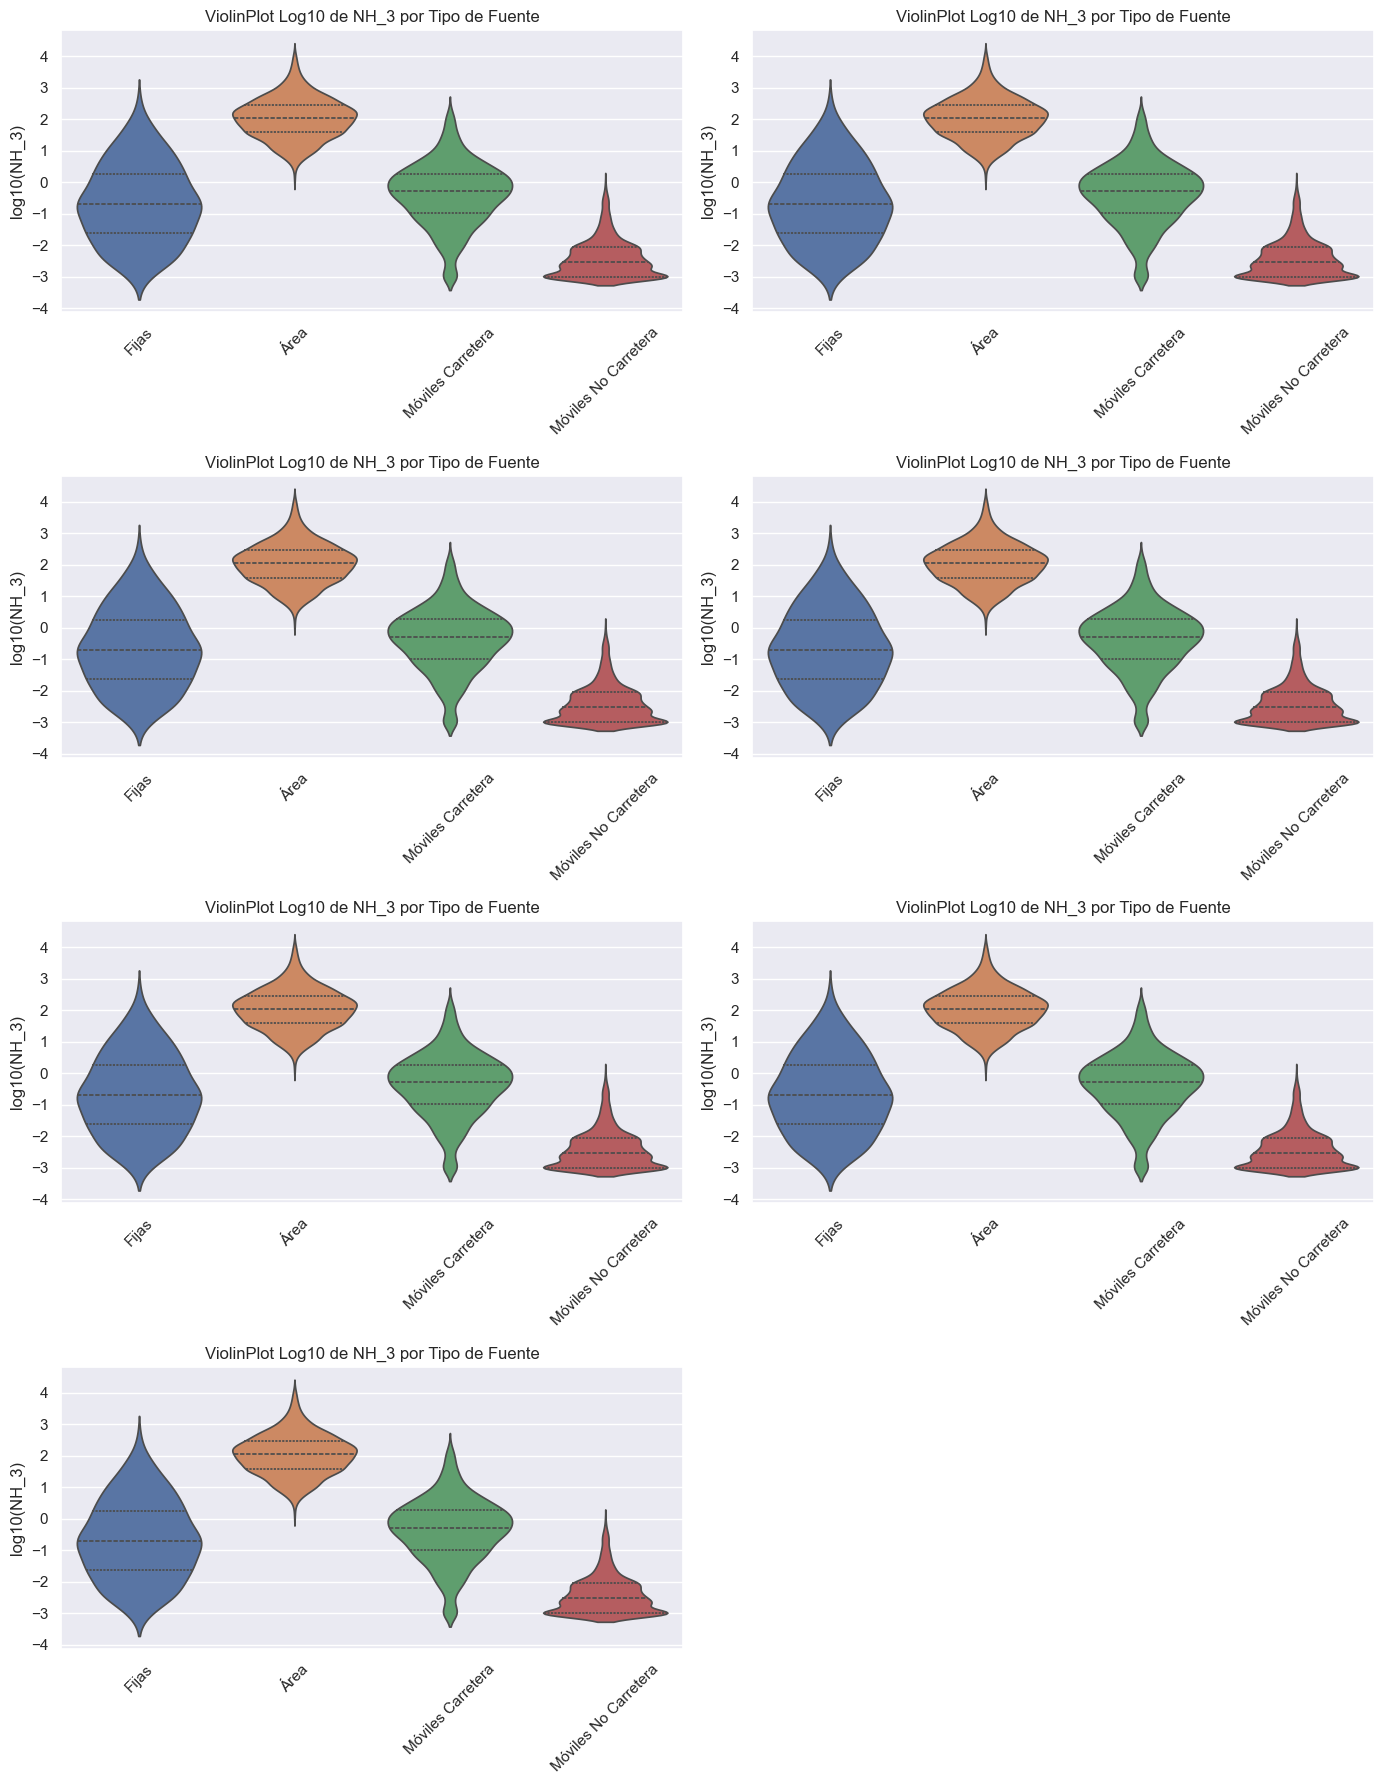

In [141]:
contaminantes = ['SO_2','CO','NOx','COV','PM_010','PM_2_5','NH_3']

fig,axes = plt.subplots(4,2,figsize=(14,18))
axes=axes.flatten()


for i,col in enumerate(contaminantes):
    ax = axes[i]

    df_plot = df_clean.copy()
    df_plot[cont] = np.log10(df_plot[cont].replace(0,np.nan))

    sns.violinplot(
        data=df_plot,
        x='Tipo_de_Fuente',
        y=cont,
        hue='Tipo_de_Fuente',
        inner='quartile',
        ax=ax
    )
    ax.set_title(f"ViolinPlot Log10 de {cont} por Tipo de Fuente")
    ax.set_xlabel("")
    ax.set_ylabel(f"log10({cont})")
    ax.tick_params(axis='x', rotation=45)

# Eliminar el subplot vacío
fig.delaxes(axes[-1])
plt.tight_layout()
plt.show()